<a href="https://colab.research.google.com/github/fanyak/portfolio/blob/main/calorie_expenditure_prediction_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --extra-index-url=https://pypi.nvidia.com "cudf-cu12==25.2.*" "cuml-cu12==25.2.*"

In [ ]:
!pip install tqdm
from tqdm import tqdm

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import typing

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_log_error

In [ ]:
# useful for q-q plots
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
!head -n 10 train.csv

id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
5,female,26,156.0,56.0,19.0,100.0,40.5,103.0
6,female,21,172.0,73.0,3.0,81.0,38.3,9.0
7,male,46,188.0,94.0,23.0,100.0,40.8,145.0
8,female,33,166.0,63.0,25.0,107.0,40.5,161.0


In [ ]:
!head -n 10 test.csv

id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
750000,male,45,177.0,81.0,7.0,87.0,39.8
750001,male,26,200.0,97.0,20.0,101.0,40.5
750002,female,29,188.0,85.0,16.0,102.0,40.4
750003,female,39,172.0,73.0,20.0,107.0,40.6
750004,female,30,173.0,67.0,16.0,94.0,40.5
750005,female,43,169.0,65.0,6.0,81.0,39.4
750006,male,74,189.0,97.0,9.0,86.0,40.0
750007,male,60,186.0,90.0,2.0,79.0,38.1
750008,male,21,196.0,91.0,4.0,84.0,38.7


In [ ]:
train_df = pd.read_csv('train.csv', index_col = None)
test_df = pd.read_csv('test.csv', index_col = None)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


In [ ]:
train_df.describe(include='all')

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,375721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,374999.500000,NaN,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,NaN,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,NaN,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,NaN,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,NaN,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,NaN,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000


In [ ]:
test_df.describe(include='all')

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,female,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,125281,NaN,NaN,NaN,NaN,NaN,NaN
mean,874999.500000,NaN,41.452464,174.725624,75.147712,15.415428,95.479084,40.036093
std,72168.927986,NaN,15.177769,12.822039,13.979513,8.349133,9.450161,0.778448
min,750000.000000,NaN,20.000000,127.000000,39.000000,1.000000,67.000000,37.100000
25%,812499.750000,NaN,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,874999.500000,NaN,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000
75%,937499.250000,NaN,52.000000,185.000000,87.000000,23.000000,103.000000,40.600000


In [ ]:
train_df.index.is_unique, test_df.index.is_unique

(True, True)

# EDA

In [ ]:
train_df.value_counts("Sex", normalize=True, dropna=False)

,proportion
Sex,
female,0.500961
male,0.499039


In [ ]:
test_df.value_counts("Sex", normalize=True, dropna=False)

,proportion
Sex,
female,0.501124
male,0.498876


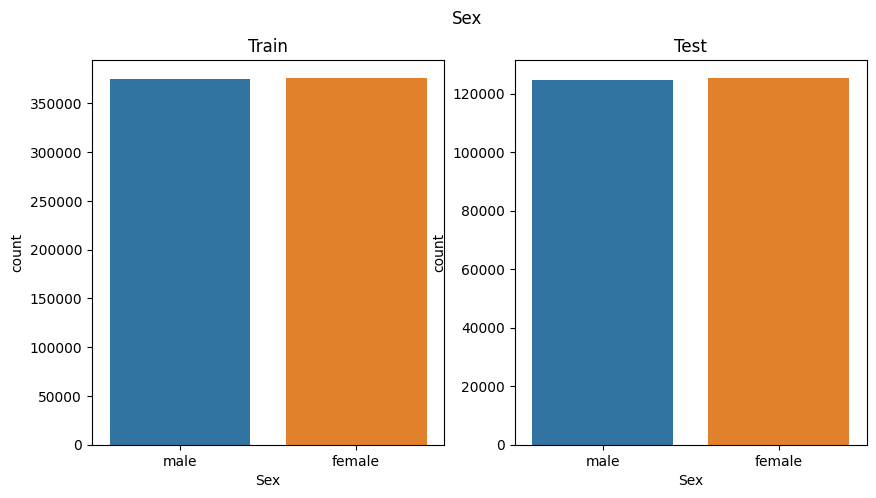

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))
sns.countplot(x = "Sex", data = train_df, hue="Sex", ax=axes[0])
sns.countplot(x = "Sex", data = test_df, hue="Sex", ax=axes[1])
axes[0].set_title('Train')
axes[1].set_title('Test')
fig.figure.suptitle('Sex')
plt.show()

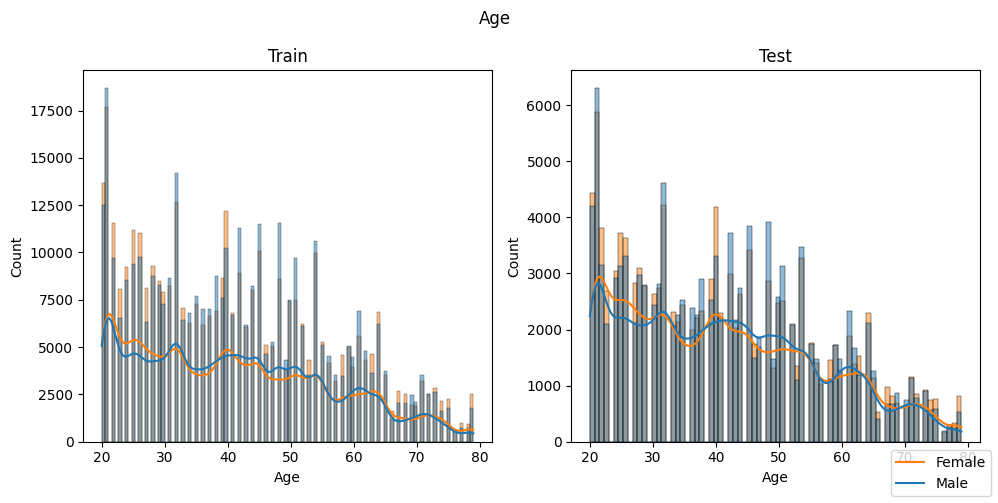

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))
sns.histplot(x = "Age", data = train_df, hue="Sex", ax=axes[0], kde=True)
sns.histplot(x = "Age", data = test_df, hue="Sex", ax=axes[1], kde=True)
axes[0].set_title('Train')
axes[1].set_title('Test')
axes[0].legend_.remove()
axes[1].legend_.remove()
fig.figure.suptitle('Age')
fig.figure.tight_layout()
fig.figure.legend(['Female','Male'], loc="lower right")
plt.show()

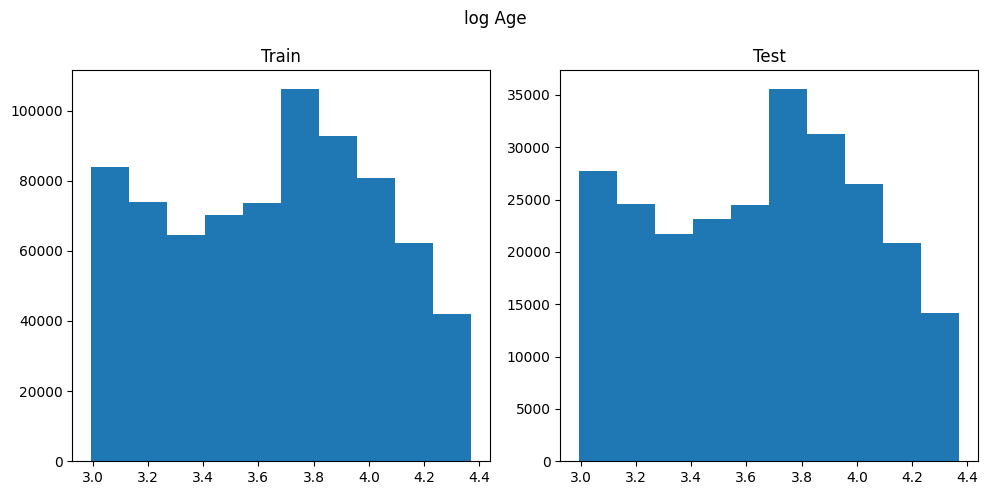

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))
axes[0].hist(train_df.Age.apply(np.log))
axes[1].hist(test_df.Age.apply(np.log))
axes[0].set_title('Train')
axes[1].set_title('Test')
fig.figure.suptitle('log Age')
fig.figure.tight_layout()
plt.show()

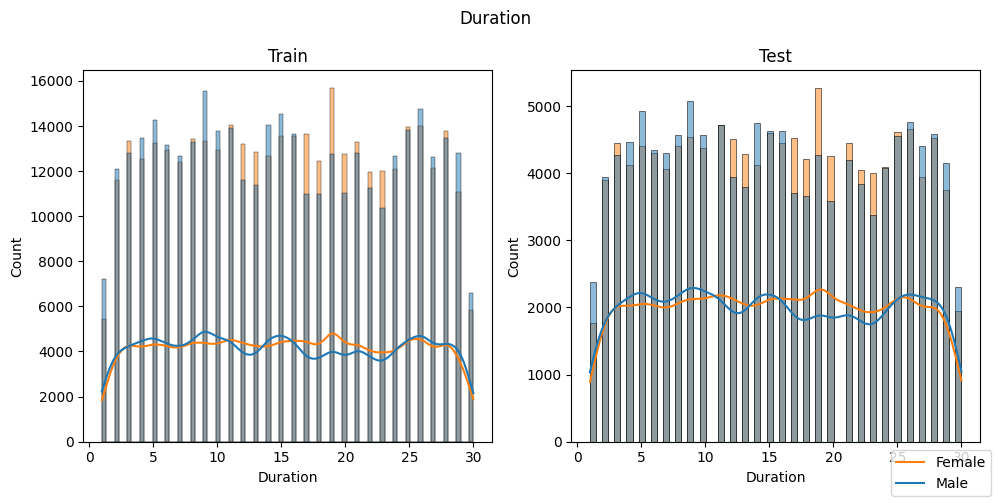

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))
sns.histplot(x= "Duration", data = train_df, hue="Sex", ax=axes[0], kde=True)
sns.histplot(x= "Duration", data = test_df, hue="Sex", ax=axes[1], kde=True)
axes[0].set_title('Train')
axes[1].set_title('Test')
axes[0].legend_ = None
axes[1].legend_ = None
fig.figure.suptitle('Duration')
fig.figure.tight_layout()
fig.figure.legend(['Female','Male'], loc="lower right")
plt.show()

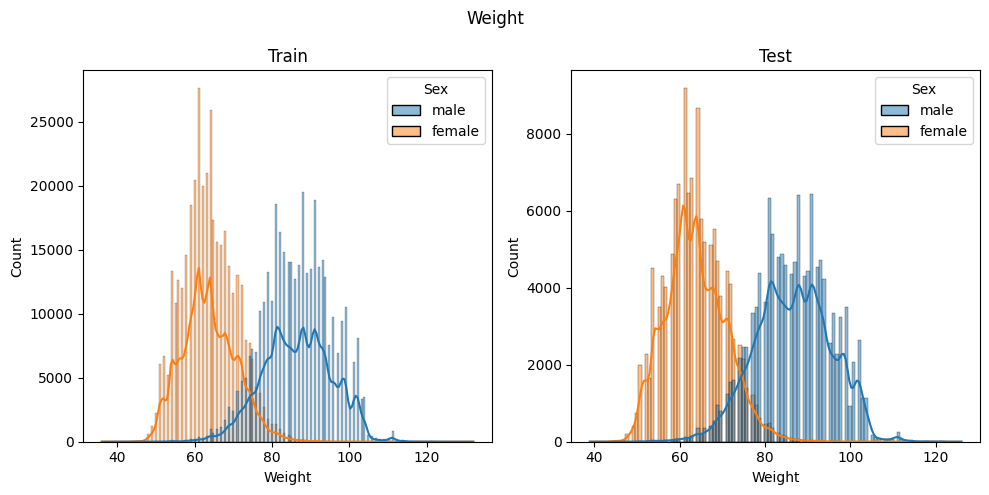

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(x= "Weight", data = train_df, hue="Sex", ax=axes[0], kde=True)
sns.histplot(x= "Weight", data = test_df, hue="Sex", ax=axes[1], kde=True)
axes[0].set_title('Train')
axes[1].set_title('Test')
# axes[0].legend_ = None
# axes[1].legend_ = None
fig.figure.suptitle('Weight')
fig.figure.tight_layout()
plt.show()

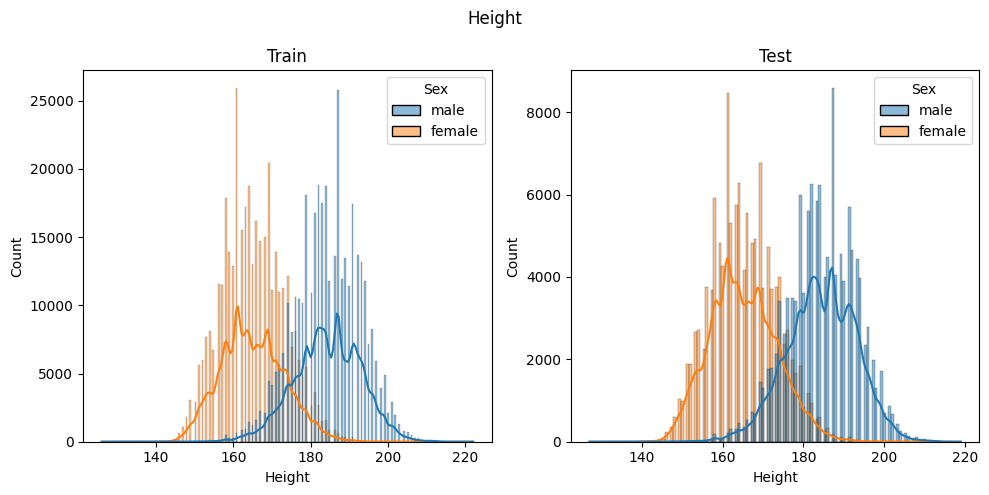

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(x= "Height", data = train_df, hue="Sex", ax=axes[0], kde=True)
sns.histplot(x= "Height", data = test_df, hue="Sex", ax=axes[1], kde=True)
axes[0].set_title('Train')
axes[1].set_title('Test')
# axes[0].legend_ = None
# axes[1].legend_ = None
fig.figure.suptitle('Height')
fig.figure.tight_layout()
plt.show()

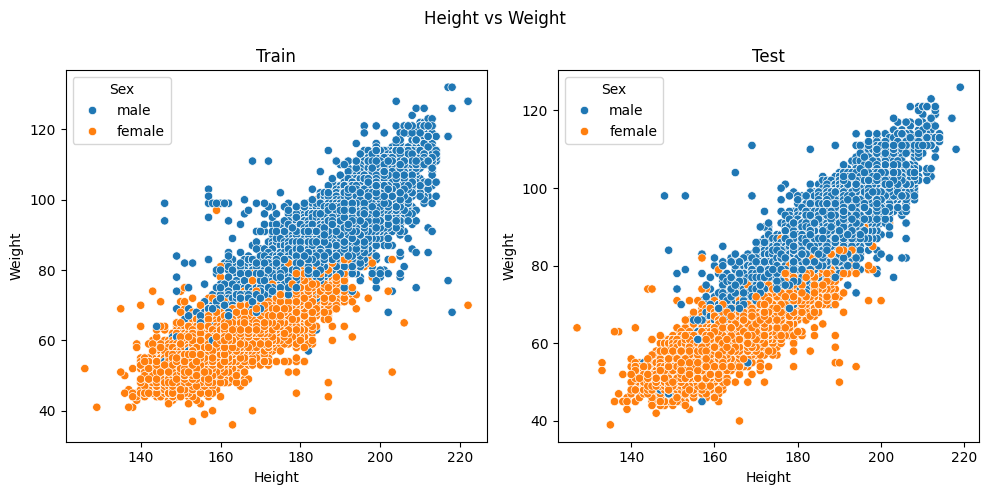

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.scatterplot(x= "Height", y= "Weight", data = train_df, hue = "Sex", ax = axes[0])
sns.scatterplot(x= "Height", y= "Weight", data = test_df, hue = "Sex", ax = axes[1])
axes[0].set_title('Train')
axes[1].set_title('Test')
# axes[0].legend_ = None
# axes[1].legend_ = None
fig.figure.suptitle('Height vs Weight')
fig.figure.tight_layout()
plt.show()

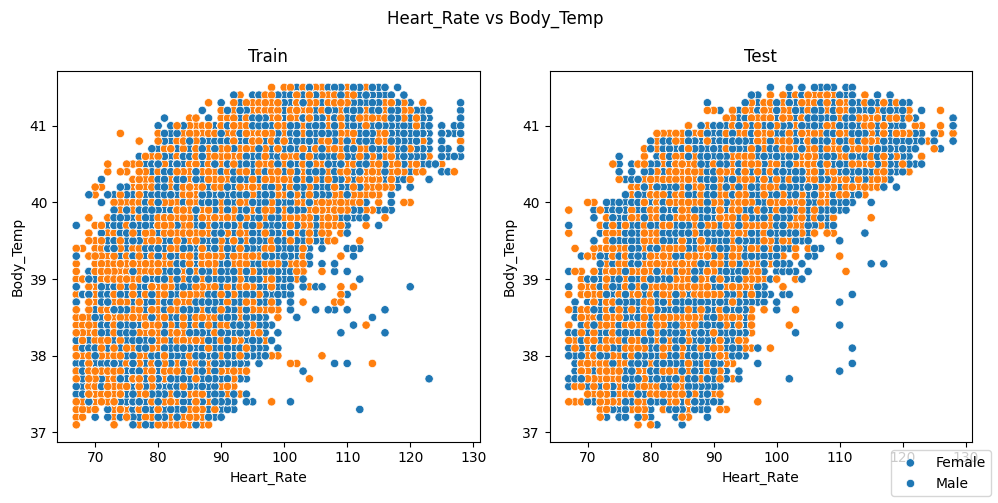

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.scatterplot(x= "Heart_Rate", y= "Body_Temp", data = train_df, hue = "Sex", ax = axes[0])
sns.scatterplot(x= "Heart_Rate", y= "Body_Temp", data = test_df, hue = "Sex", ax = axes[1])
axes[0].set_title('Train')
axes[1].set_title('Test')
axes[0].legend_ = None
axes[1].legend_ = None
fig.figure.suptitle('Heart_Rate vs Body_Temp')
fig.figure.tight_layout()
fig.figure.legend(['Female','Male'], loc="lower right")
plt.show()

## Relationships with Target Calories

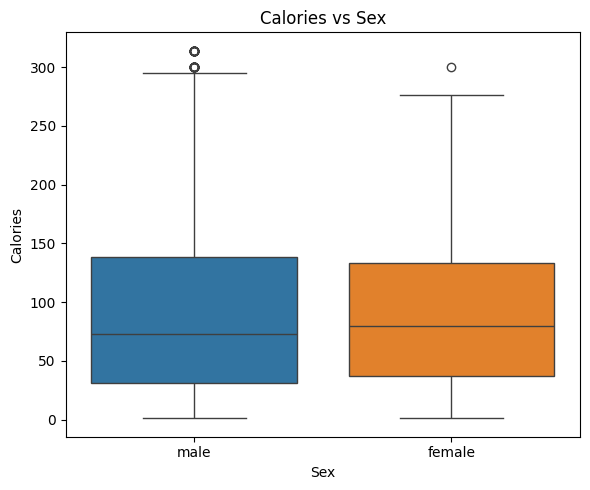

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Sex", y="Calories", data = train_df, hue="Sex")
plt.title('Calories vs Sex')
plt.tight_layout()
plt.show()

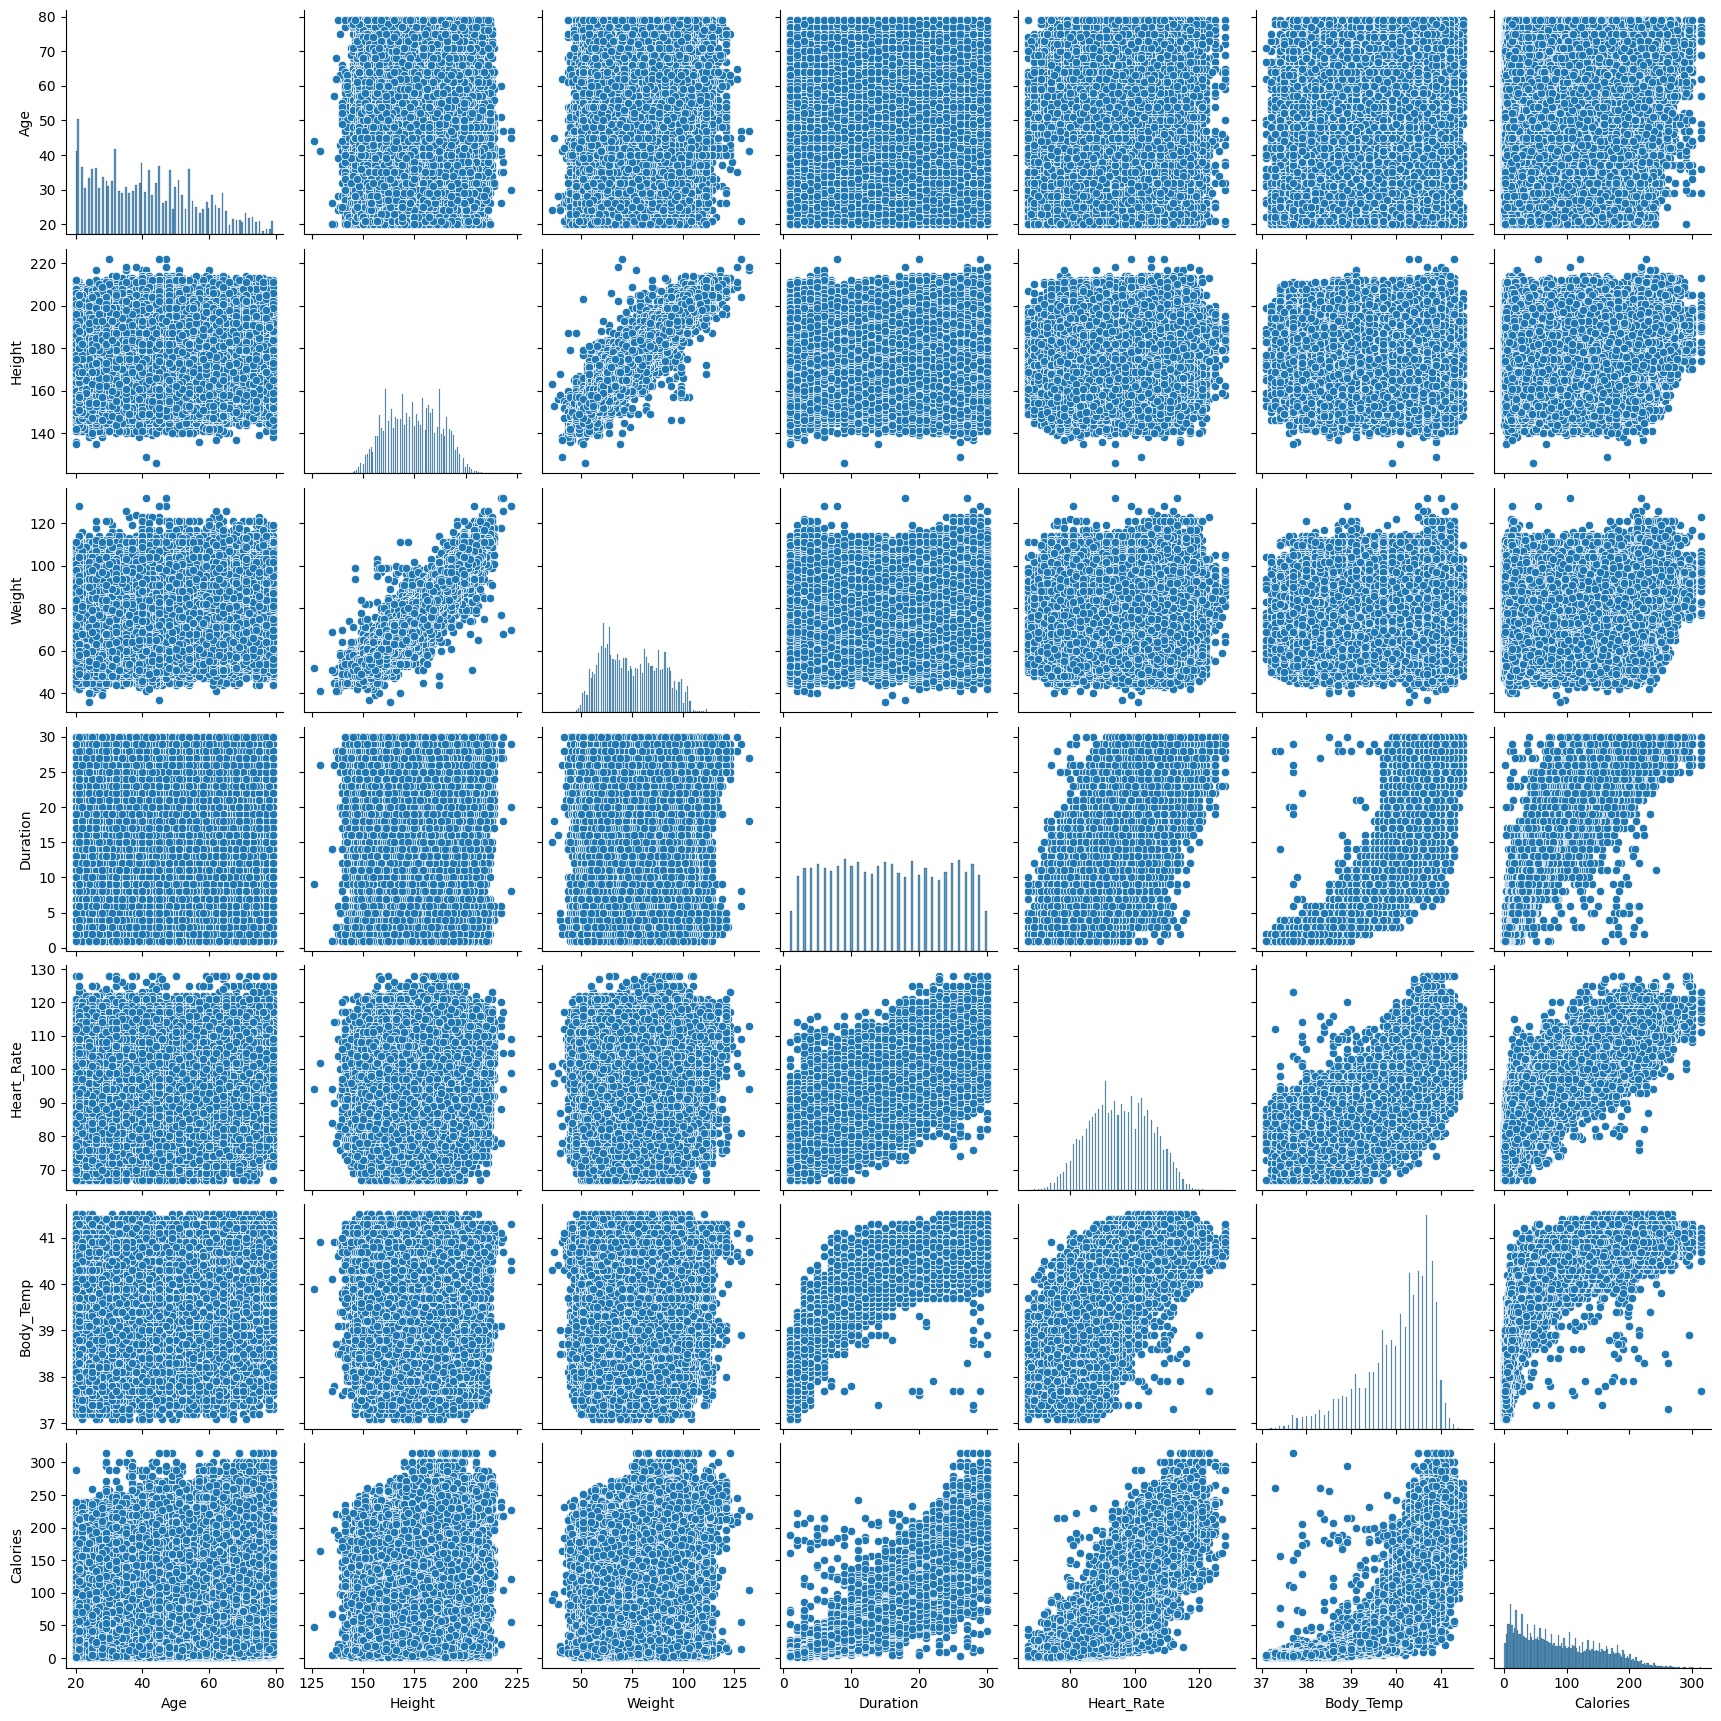

In [ ]:
sns.pairplot(train_df.iloc[:, 2:])

In [ ]:
train_df.iloc[:, 2:-1].corrwith(train_df.Calories)

,0
Age,0.145683
Height,-0.004026
Weight,0.015863
Duration,0.959908
Heart_Rate,0.908748
Body_Temp,0.828671


<Axes: >

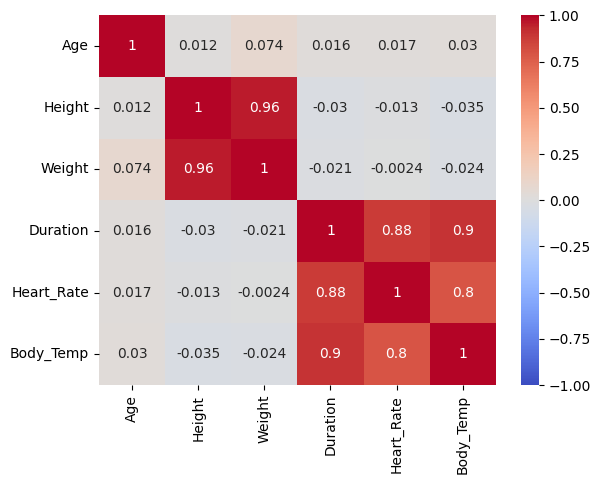

In [ ]:
sns.heatmap(train_df.iloc[:, 2:-1].corr(), vmin=-1, vmax=1, annot=True, cmap='coolwarm')

In [ ]:
train_df.loc[:, "tableau_heart_rate"] = 3.37303e-06*train_df.Heart_Rate.pow(5) + -0.00172897*train_df.Heart_Rate.pow(4) + 0.346811*train_df.Heart_Rate.pow(3) + -33.993*train_df.Heart_Rate.pow(3) + 1631.49*train_df.Heart_Rate

<Axes: xlabel='tableau_heart_rate', ylabel='Calories'>

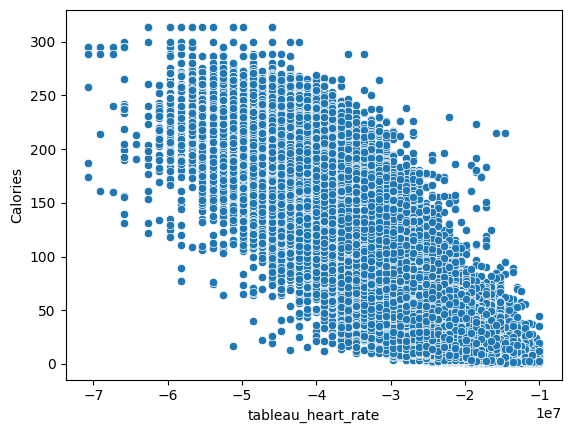

In [ ]:
sns.scatterplot(x=train_df["tableau_heart_rate"], y=train_df.Calories)

In [ ]:
train_df.loc[:, "tableau_body_temp"] =  1.22608*train_df.Body_Temp

<Axes: xlabel='tableau_body_temp', ylabel='Calories'>

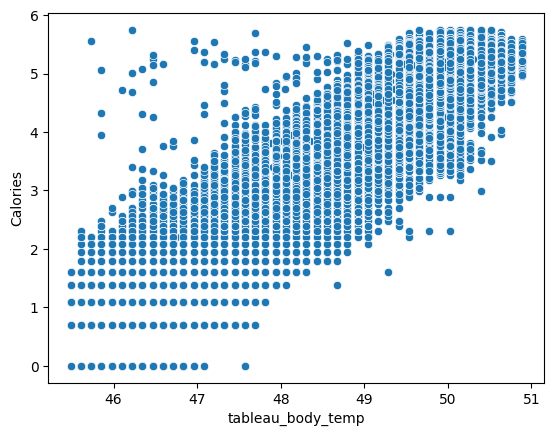

In [ ]:
sns.scatterplot(x=train_df["tableau_body_temp"], y=np.log(train_df.Calories))

## try preprocessing

In [ ]:
# sns.scatterplot(x=train_df.Body_Temp.apply(np.exp), y=train_df.Calories)
from sklearn.preprocessing import PowerTransformer
dt = train_df.iloc[:, 2:].copy()
pt = PowerTransformer(method = 'box-cox', standardize= False)
dt_transform = pt.fit_transform(dt)
dt_transform = pd.DataFrame(dt_transform, columns=dt.columns)

<Axes: xlabel='Body_Temp', ylabel='Calories'>

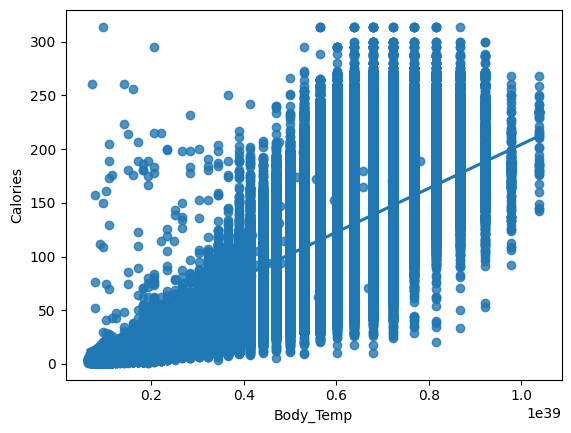

In [ ]:
sns.regplot(x=dt_transform.Body_Temp, y=train_df.Calories)

<Axes: xlabel='Body_Temp', ylabel='Calories'>

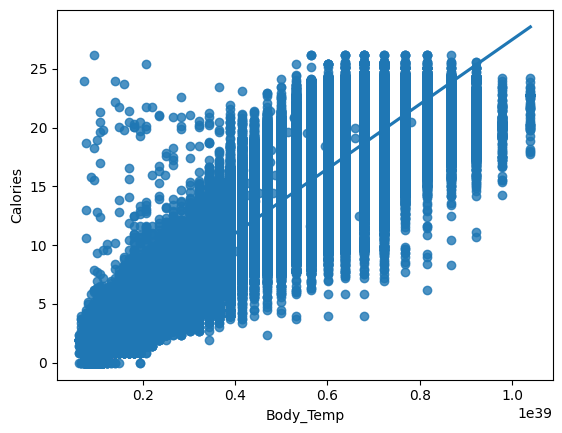

In [ ]:

sns.regplot(x=dt_transform.Body_Temp, y= dt_transform.Calories)

In [ ]:
dt_transform.Body_Temp.corr(dt_transform.Calories)

np.float64(0.9347822654377714)

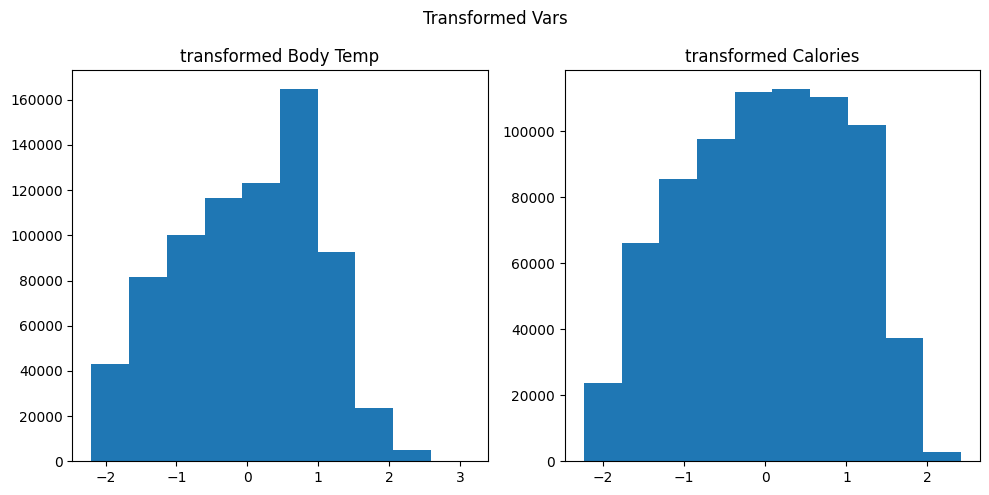

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10, 5))
axes[0].hist(dt_transform.Body_Temp)
axes[1].hist(dt_transform.Calories)
axes[0].set_title('Transformed Body Temp')
axes[1].set_title('Transformed Calories')
fig.figure.suptitle('Transformed Vars')
fig.figure.tight_layout()
plt.show()

In [ ]:
train_df.loc[:, 'Body_Temp_transform'] = dt_transform.Body_Temp.values
preprocess_ols_formula = 'Calories ~ Body_Temp_transform'
OLS = ols(formula = preprocess_ols_formula, data = train_df)
model = OLS.fit()
model.summary()

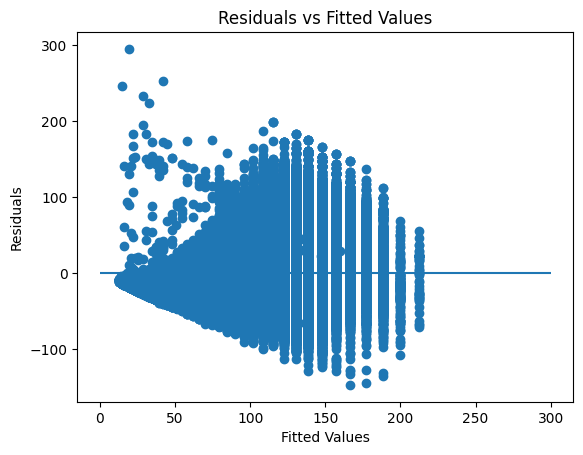

In [ ]:
plt.scatter(model.fittedvalues, model.resid)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.hlines(y=0, xmin=0, xmax=300)
plt.title('Residuals vs Fitted Values')
plt.show()

# Check for Duplicates

In [ ]:
train_df.duplicated(subset=train_df.columns[1:]).sum()

np.int64(2841)

In [ ]:
duplication_cond = train_df.duplicated(subset=train_df.columns[1:])
train_df.loc[duplication_cond, :]

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
11643,11643,female,54,161.0,61.0,14.0,95.0,40.3,76.0
18100,18100,female,54,161.0,61.0,9.0,88.0,39.7,42.0
22070,22070,male,51,187.0,94.0,3.0,81.0,38.8,10.0
26664,26664,female,67,169.0,69.0,24.0,104.0,40.7,161.0
31062,31062,female,40,161.0,58.0,14.0,90.0,40.4,64.0
...,...,...,...,...,...,...,...,...,...
749584,749584,female,39,161.0,61.0,13.0,99.0,40.3,74.0
749823,749823,female,29,173.0,68.0,14.0,95.0,40.2,67.0
749852,749852,male,21,187.0,90.0,9.0,91.0,39.7,30.0
749889,749889,male,40,191.0,88.0,5.0,86.0,39.0,18.0


# Clean and Load

In [ ]:
def clean_columns_df(df: pd.DataFrame) -> pd.DataFrame:
  X = df.copy()
  X.columns = [col.strip().lower() for col in X.columns]
  return X

In [ ]:
def round_floats_df(df: pd.DataFrame) -> pd.DataFrame:
  X = df.copy()
  for col in X.columns:
    if X[col].dtype == 'float64':
      X[col] = X[col].round(2)
  return X

In [ ]:
def load() -> typing.List[pd.DataFrame]:
  train = pd.read_csv('./train.csv', index_col = None)
  test = pd.read_csv('./test.csv', index_col = None)
  train_df = clean_columns_df(train)
  test_df = clean_columns_df(test)
  train_df = round_floats_df(train_df)
  test_df = round_floats_df(test_df)
  return train_df, test_df

In [ ]:
train, test = load()

# drop duplicates inplace and check

In [ ]:
train.loc[duplication_cond, :]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories
11643,11643,female,54,161.0,61.0,14.0,95.0,40.3,76.0
18100,18100,female,54,161.0,61.0,9.0,88.0,39.7,42.0
22070,22070,male,51,187.0,94.0,3.0,81.0,38.8,10.0
26664,26664,female,67,169.0,69.0,24.0,104.0,40.7,161.0
31062,31062,female,40,161.0,58.0,14.0,90.0,40.4,64.0
...,...,...,...,...,...,...,...,...,...
749584,749584,female,39,161.0,61.0,13.0,99.0,40.3,74.0
749823,749823,female,29,173.0,68.0,14.0,95.0,40.2,67.0
749852,749852,male,21,187.0,90.0,9.0,91.0,39.7,30.0
749889,749889,male,40,191.0,88.0,5.0,86.0,39.0,18.0


In [ ]:
train_1 = train.drop_duplicates(subset=train.columns[1:])
# check drop
train_1.loc[duplication_cond, :]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories


# Outliers

In [ ]:
train_1_m = train_1[train_1.sex == 'male']
train_1_f = train_1[train_1.sex == 'female']

In [ ]:
lower_bound_height = train_1_m.height.quantile(0.25)
upper_bound_height = train_1_m.height.quantile(0.75)
iq_height = upper_bound_height - lower_bound_height
lower_bound_height = lower_bound_height - 1.5 * iq_height
upper_bound_height = upper_bound_height + 1.5 * iq_height
train_1_m[(train_1_m.height < lower_bound_height) | (train_1_m.height > upper_bound_height)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories
42,42,male,78,158.0,59.0,20.0,94.0,40.7,133.0
787,787,male,47,157.0,63.0,7.0,89.0,39.3,31.0
871,871,male,54,157.0,61.0,27.0,109.0,40.8,204.0
950,950,male,28,160.0,64.0,2.0,76.0,38.2,2.0
1040,1040,male,62,160.0,62.0,12.0,87.0,39.9,55.0
...,...,...,...,...,...,...,...,...,...
747543,747543,male,74,158.0,60.0,23.0,99.0,40.7,167.0
747733,747733,male,64,152.0,57.0,27.0,105.0,41.1,179.0
748353,748353,male,64,158.0,64.0,5.0,92.0,38.8,24.0
748476,748476,male,56,158.0,69.0,24.0,104.0,40.6,159.0


In [ ]:
lower_bound_height = train_1_f.height.quantile(0.25)
upper_bound_height = train_1_f.height.quantile(0.75)
iq_height = upper_bound_height - lower_bound_height
lower_bound_height = lower_bound_height - 1.5 * iq_height
upper_bound_height = upper_bound_height + 1.5 * iq_height
train_1_f[(train_1_f.height < lower_bound_height) | (train_1_f.height > upper_bound_height)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories
975,975,female,24,193.0,88.0,12.0,99.0,39.8,61.0
977,977,female,68,196.0,89.0,16.0,105.0,40.1,100.0
4017,4017,female,24,191.0,79.0,6.0,85.0,39.8,22.0
4537,4537,female,24,195.0,96.0,17.0,99.0,40.6,86.0
4604,4604,female,40,191.0,78.0,4.0,81.0,39.0,12.0
...,...,...,...,...,...,...,...,...,...
744687,744687,female,52,140.0,53.0,26.0,106.0,41.0,170.0
744796,744796,female,63,190.0,91.0,19.0,97.0,40.7,116.0
746823,746823,female,20,135.0,51.0,14.0,94.0,40.1,67.0
748934,748934,female,63,194.0,90.0,24.0,104.0,40.8,166.0


In [ ]:
lower_bound_weight = train_1_m.weight.quantile(0.25)
upper_bound_weight = train_1_m.weight.quantile(0.75)
iq_weight = upper_bound_weight - lower_bound_weight
lower_bound_weight = lower_bound_weight - 1.5 * iq_weight
upper_bound_weight = upper_bound_weight + 1.5 * iq_weight
train_1_m[(train_1_m.weight < lower_bound_weight) | (train_1_m.weight > upper_bound_weight)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories
42,42,male,78,158.0,59.0,20.0,94.0,40.7,133.0
189,189,male,25,162.0,62.0,26.0,104.0,40.7,145.0
871,871,male,54,157.0,61.0,27.0,109.0,40.8,204.0
1040,1040,male,62,160.0,62.0,12.0,87.0,39.9,55.0
1248,1248,male,35,171.0,61.0,5.0,85.0,39.2,17.0
...,...,...,...,...,...,...,...,...,...
747770,747770,male,30,161.0,62.0,5.0,94.0,39.1,18.0
747916,747916,male,39,162.0,58.0,18.0,93.0,40.5,64.0
748849,748849,male,64,161.0,62.0,14.0,102.0,40.5,95.0
749041,749041,male,38,163.0,62.0,9.0,89.0,39.6,27.0


In [ ]:
lower_bound_weight = train_1_f.weight.quantile(0.25)
upper_bound_weight = train_1_f.weight.quantile(0.75)
iq_weight = upper_bound_weight - lower_bound_weight
lower_bound_weight = lower_bound_weight - 1.5 * iq_weight
upper_bound_weight = upper_bound_weight + 1.5 * iq_weight
train_1_f[(train_1_f.weight < lower_bound_weight) | (train_1_f.weight > upper_bound_weight)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories
48,48,female,45,183.0,82.0,25.0,99.0,41.1,136.0
223,223,female,21,185.0,84.0,24.0,109.0,40.9,147.0
446,446,female,36,180.0,82.0,8.0,94.0,39.8,37.0
543,543,female,69,186.0,94.0,8.0,82.0,39.6,32.0
975,975,female,24,193.0,88.0,12.0,99.0,39.8,61.0
...,...,...,...,...,...,...,...,...,...
748934,748934,female,63,194.0,90.0,24.0,104.0,40.8,166.0
749368,749368,female,25,194.0,91.0,15.0,104.0,40.0,75.0
749554,749554,female,58,177.0,82.0,23.0,101.0,40.7,143.0
749611,749611,female,22,187.0,87.0,20.0,95.0,40.8,87.0


In [ ]:
lower_bound_duration = train_1.duration.quantile(0.25)
upper_bound_duration = train_1.duration.quantile(0.75)
iq_duration = upper_bound_duration - lower_bound_duration
lower_bound_duration = lower_bound_duration - 1.5 * iq_duration
upper_bound_duration = upper_bound_duration + 1.5 * iq_duration
train_1[(train_1.duration < lower_bound_duration) | (train_1.duration > upper_bound_duration)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories


In [ ]:
lower_bound_temp = train_1.body_temp.quantile(0.25)
upper_bound_temp = train_1.body_temp.quantile(0.75)
iq_temp = upper_bound_temp - lower_bound_temp
lower_bound_temp = lower_bound_temp - 1.5 * iq_temp
upper_bound_temp = upper_bound_temp + 1.5 * iq_temp
train_1[(train_1.body_temp < lower_bound_temp) | (train_1.body_temp > upper_bound_temp)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories
17,17,female,51,171.0,71.0,1.0,77.0,37.7,3.0
40,40,female,71,178.0,79.0,1.0,76.0,37.6,4.0
66,66,female,32,158.0,57.0,1.0,76.0,37.9,4.0
105,105,male,41,195.0,93.0,2.0,81.0,37.5,5.0
132,132,female,40,156.0,58.0,2.0,81.0,37.8,7.0
...,...,...,...,...,...,...,...,...,...
749740,749740,male,26,194.0,88.0,1.0,80.0,37.9,3.0
749892,749892,male,20,190.0,90.0,2.0,77.0,37.7,2.0
749907,749907,male,40,179.0,78.0,2.0,84.0,37.7,6.0
749914,749914,female,31,153.0,53.0,1.0,83.0,37.8,4.0


Outlier values seem normal. Leave them in the data

# Dummy Encoding

In [ ]:
def create_sex_dummy(df: pd.DataFrame) -> pd.DataFrame:
  X = df[["id", "sex"]].copy()
  return pd.get_dummies(X, columns=['sex'], drop_first=True, dtype=int)

In [ ]:
train_dummy = create_sex_dummy(train_1).rename(columns={"sex_male": "male"})
test_dummy = create_sex_dummy(test).rename(columns={"sex_male": "male"})

In [ ]:
train_1 = train_1.merge(train_dummy, on="id")
test = test.merge(test_dummy, on="id")

In [ ]:
train_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          747159 non-null  int64  
 1   sex         747159 non-null  object 
 2   age         747159 non-null  int64  
 3   height      747159 non-null  float64
 4   weight      747159 non-null  float64
 5   duration    747159 non-null  float64
 6   heart_rate  747159 non-null  float64
 7   body_temp   747159 non-null  float64
 8   calories    747159 non-null  float64
 9   male        747159 non-null  int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 57.0+ MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   sex         250000 non-null  object 
 2   age         250000 non-null  int64  
 3   height      250000 non-null  float64
 4   weight      250000 non-null  float64
 5   duration    250000 non-null  float64
 6   heart_rate  250000 non-null  float64
 7   body_temp   250000 non-null  float64
 8   male        250000 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 17.2+ MB


### sanity check

In [ ]:
train_1[(train_1.sex == "male") & (train_1.male != 1.0)]

,id,sex,age,height,weight,duration,heart_rate,body_temp,calories,male


In [ ]:
test[(test.sex == "female")].male.sum() # must be zero!!

np.int64(0)

# Feature Engineering

## features from literature

In [ ]:
def calculate_BMR(df: pd.DataFrame) -> pd.DataFrame:
  X = pd.DataFrame()
  X = df.loc[:, ["id"]].copy()
  X.loc[:, 'BMR'] = np.where(df.sex == "male", 88.362 + (13.397 * df.weight) + (4.799 * df.height) - (5.677 * df.age), 447.593 + (9.247 * df.weight) + (3.098 * df.height) - (4.330 * df.age))
  X['BMR'] = X.BMR.round(2)
  return X

In [ ]:
def calculate_BMI(df: pd.DataFrame) -> pd.DataFrame:
  X = pd.DataFrame()
  X = df.loc[:, ["id"]].copy()
  X.loc[:, "BMI"] = (df.weight / ((df.height/100) ** 2)).round(2)
  return  X

In [ ]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
  X_BMR = calculate_BMR(df)
  X_BMI = calculate_BMI(df)
  return X_BMR.merge(X_BMI, on="id")

In [ ]:
train_features = create_features(train_1)
test_features = create_features(test)
train_features.isna().sum(), test_features.isna().sum()

(id     0
 BMR    0
 BMI    0
 dtype: int64,
 id     0
 BMR    0
 BMI    0
 dtype: int64)

In [ ]:
train_1 = train_1.merge(train_features, on="id")
test = test.merge(test_features, on="id")

In [ ]:
train_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          747159 non-null  int64  
 1   sex         747159 non-null  object 
 2   age         747159 non-null  int64  
 3   height      747159 non-null  float64
 4   weight      747159 non-null  float64
 5   duration    747159 non-null  float64
 6   heart_rate  747159 non-null  float64
 7   body_temp   747159 non-null  float64
 8   calories    747159 non-null  float64
 9   male        747159 non-null  int64  
 10  BMR         747159 non-null  float64
 11  BMI         747159 non-null  float64
dtypes: float64(8), int64(3), object(1)
memory usage: 68.4+ MB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   sex         250000 non-null  object 
 2   age         250000 non-null  int64  
 3   height      250000 non-null  float64
 4   weight      250000 non-null  float64
 5   duration    250000 non-null  float64
 6   heart_rate  250000 non-null  float64
 7   body_temp   250000 non-null  float64
 8   male        250000 non-null  int64  
 9   BMR         250000 non-null  float64
 10  BMI         250000 non-null  float64
dtypes: float64(7), int64(3), object(1)
memory usage: 21.0+ MB


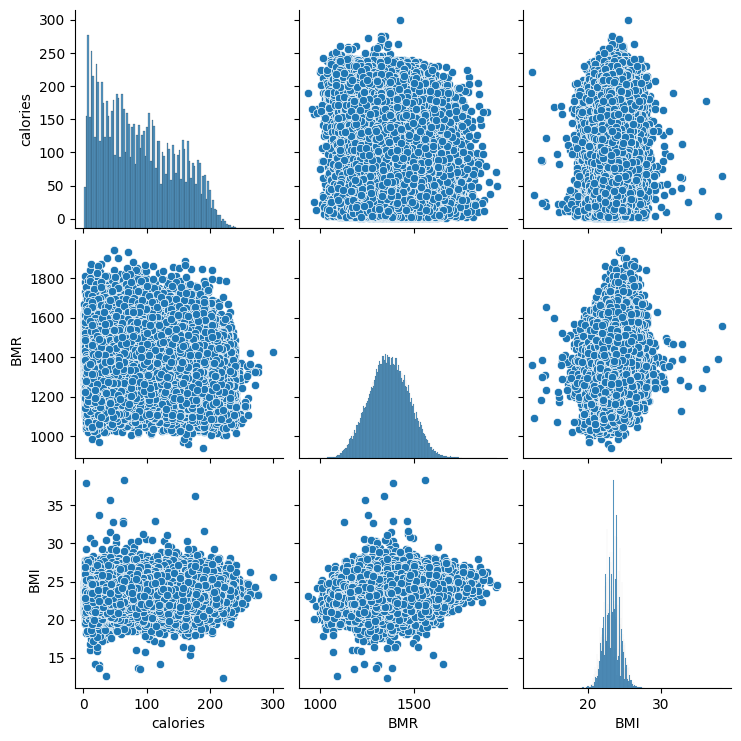

In [ ]:
sns.pairplot(train_1.loc[train_1.sex == "female", ["sex", "calories", "BMR", "BMI"]])

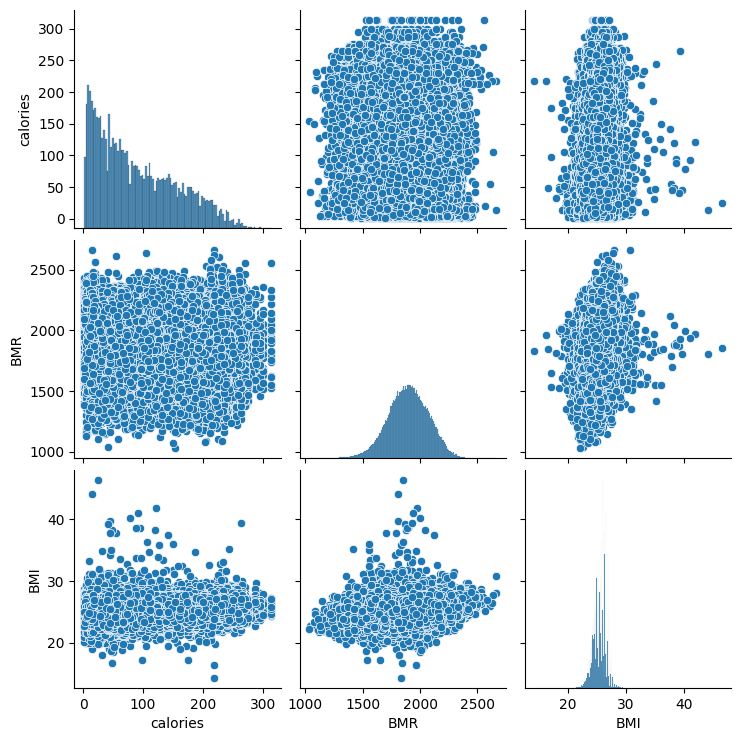

In [ ]:
sns.pairplot(train_1.loc[train_1.sex == "male", ["sex", "calories", "BMR", "BMI"]])

# Mutual Information

Mutual Information is suitable for non-linear relationships

In [ ]:
from sklearn.feature_selection import mutual_info_regression

In [ ]:
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [ ]:
X_mi = train_1.loc[:, ["male", "age", "height", "weight", "duration", "heart_rate", "body_temp"]]
y_mi = train_1.loc[:, "calories"]

In [ ]:
mi_scores = make_mi_scores(X_mi, y_mi)
mi_scores

,MI Scores
duration,1.638321
body_temp,1.120308
heart_rate,0.975684
age,0.096597
weight,0.055198
height,0.053393
male,0.016469


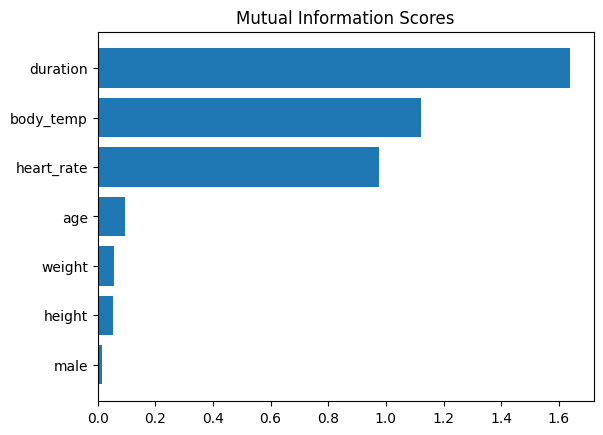

In [ ]:
plot_mi_scores(mi_scores)

it seems strange that sex doesn't seem to have a higher impact. There must be an interaction between the categories of sex and other independent

# K-Means Clustering (Unsupervised Learning)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
def cluster_labels(df: pd.DataFrame, features: typing.List[str], \
                   n_clusters = 7) -> pd.DataFrame:
    X = df.copy()
    X_scaled = X.loc[:, features]
    X_scaled = (X_scaled - X_scaled.mean(axis=0)) / X_scaled.std(axis=0)
    kmeans = KMeans(n_clusters = n_clusters, n_init=50, random_state=0)
    X_new = pd.DataFrame()
    X_new.loc[:, "id"] = df.id
    X_new["Cluster"] = kmeans.fit_predict(X_scaled)
    return X_new


def cluster_distance(df: pd.DataFrame, features: typing.List[str], \
                     n_clusters = 7) -> pd.DataFrame:
    X = df.copy()
    X_scaled = X.loc[:, features]
    X_scaled = (X_scaled - X_scaled.mean(axis=0)) / X_scaled.std(axis=0)
    kmeans = KMeans(n_clusters =  n_clusters, n_init = 50, random_state=0)
    X_cd = kmeans.fit_transform(X_scaled)
    # Label features and join to dataset
    X_cd = pd.DataFrame(
        X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])]
    )
    X_cd.loc[:, "id"] = df.id.values
    return X_cd

In [ ]:
# train
X_cluster_data = train_1.copy()
y_cluster_data = X_cluster_data.pop("calories") #unsupervised learning\

# test
test_cluster_data = test.copy()

In [ ]:
cluster_features = X_cluster_data.columns[2:-2]
cluster_features

Index(['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp',
       'male'],
      dtype='object')

In [ ]:
X_cluster_lbls = cluster_labels(X_cluster_data, cluster_features)
X_cluster_dist = cluster_distance(X_cluster_data, cluster_features)

In [ ]:
test_cluster_lbls = cluster_labels(test_cluster_data, cluster_features)
test_cluster_dist = cluster_distance(test_cluster_data, cluster_features)

<Axes: xlabel='Cluster', ylabel='calories'>

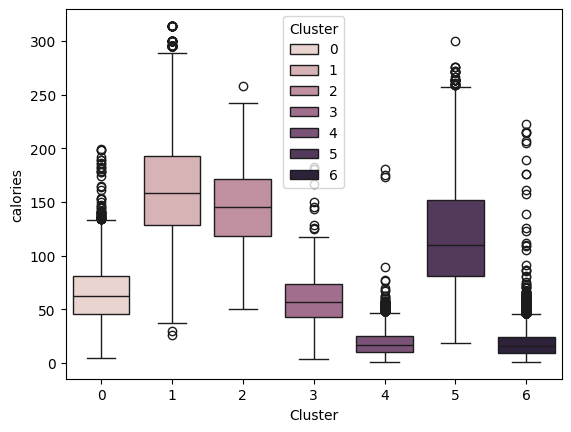

In [ ]:
sns.boxplot(x = X_cluster_lbls.Cluster, y = y_cluster_data, hue = X_cluster_lbls.Cluster)

In [ ]:
X_cluster_dist.head()

,Centroid_0,Centroid_1,Centroid_2,Centroid_3,Centroid_4,Centroid_5,Centroid_6,id
0,2.149031,0.882201,3.140680,3.772951,5.128664,3.557740,4.163162,0
1,3.800245,4.780008,3.726316,2.270589,1.884197,2.291017,3.745176,1
2,3.500059,4.614291,3.426430,1.638721,1.397670,2.454982,3.480827,2
3,2.484261,1.585421,3.611746,4.192458,5.487904,4.427931,4.314034,3
4,3.564099,3.133016,0.502921,1.997749,3.834001,1.711115,4.911159,4


In [ ]:
test_cluster_dist.head()

,Centroid_0,Centroid_1,Centroid_2,Centroid_3,Centroid_4,Centroid_5,Centroid_6,id
0,1.456681,2.787134,3.410886,2.779124,1.358837,3.191466,4.016338,750000
1,3.677708,4.405003,4.678592,5.361593,2.084271,1.904073,4.267972,750001
2,3.706471,2.690301,3.160168,3.926061,2.376045,2.470927,2.674134,750002
3,4.460616,2.160999,1.852072,3.873947,3.006973,2.517255,1.166307,750003
4,3.837706,1.046157,2.253481,2.881750,2.766833,3.169946,1.691522,750004


In [ ]:
train_cluster = train_1.copy()
# by default DataFrame.join uses Other's index but we can use any column in df.
# this method This method preserves the original DataFrame’s index in the resul
train_cluster = train_cluster.join(X_cluster_lbls.set_index('id'), on='id')
train_cluster = train_cluster.join(X_cluster_dist.set_index('id'), on='id')

In [ ]:
test_cluster = test.copy()
# by default DataFrame.join uses Other's index but we can use any column in df.
# this method This method preserves the original DataFrame’s index in the resul
test_cluster = test_cluster.join(test_cluster_lbls.set_index('id'), on='id')
test_cluster = test_cluster.join(test_cluster_dist.set_index('id'), on='id')

In [ ]:
train_cluster.Cluster = train_cluster.Cluster.astype("category")
test_cluster.Cluster = test_cluster.Cluster.astype("category")

<Axes: xlabel='Cluster', ylabel='duration'>

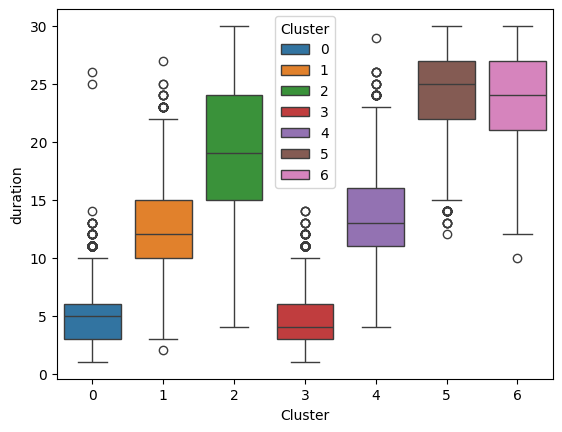

In [ ]:
sns.boxplot(x = "Cluster", y="duration", data = test_cluster, hue = "Cluster")

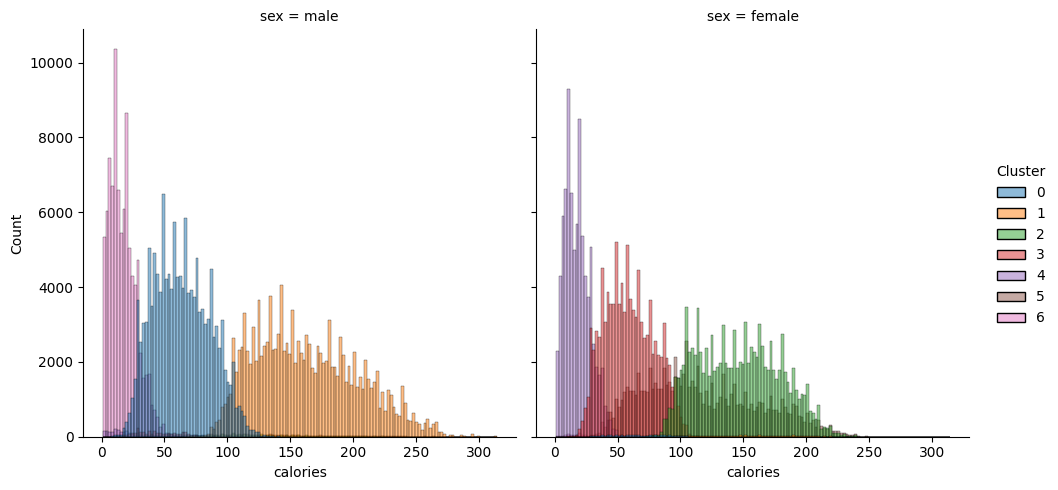

In [ ]:
sns.displot(x="calories", hue="Cluster", col="sex", data = train_cluster)

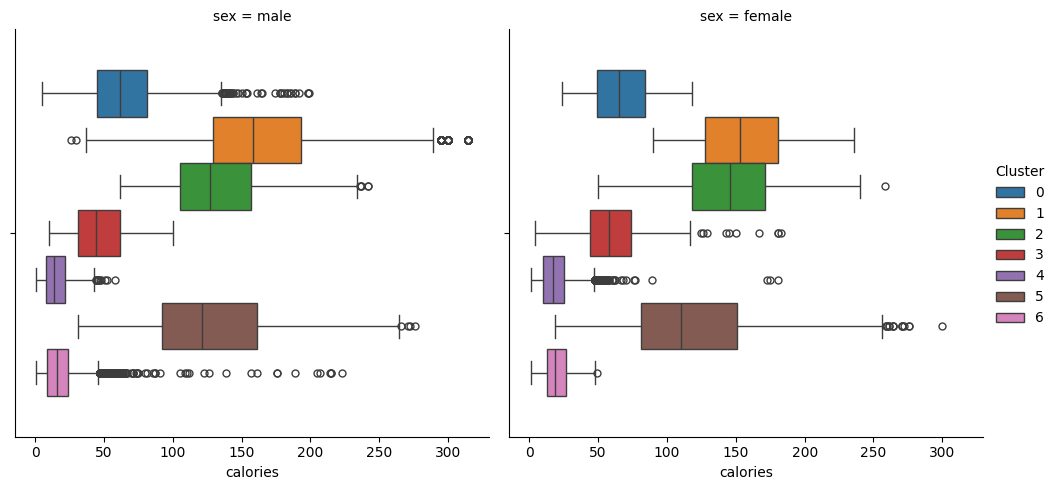

In [ ]:
sns.catplot(x="calories", hue="Cluster", col="sex", data = train_cluster, kind="box")

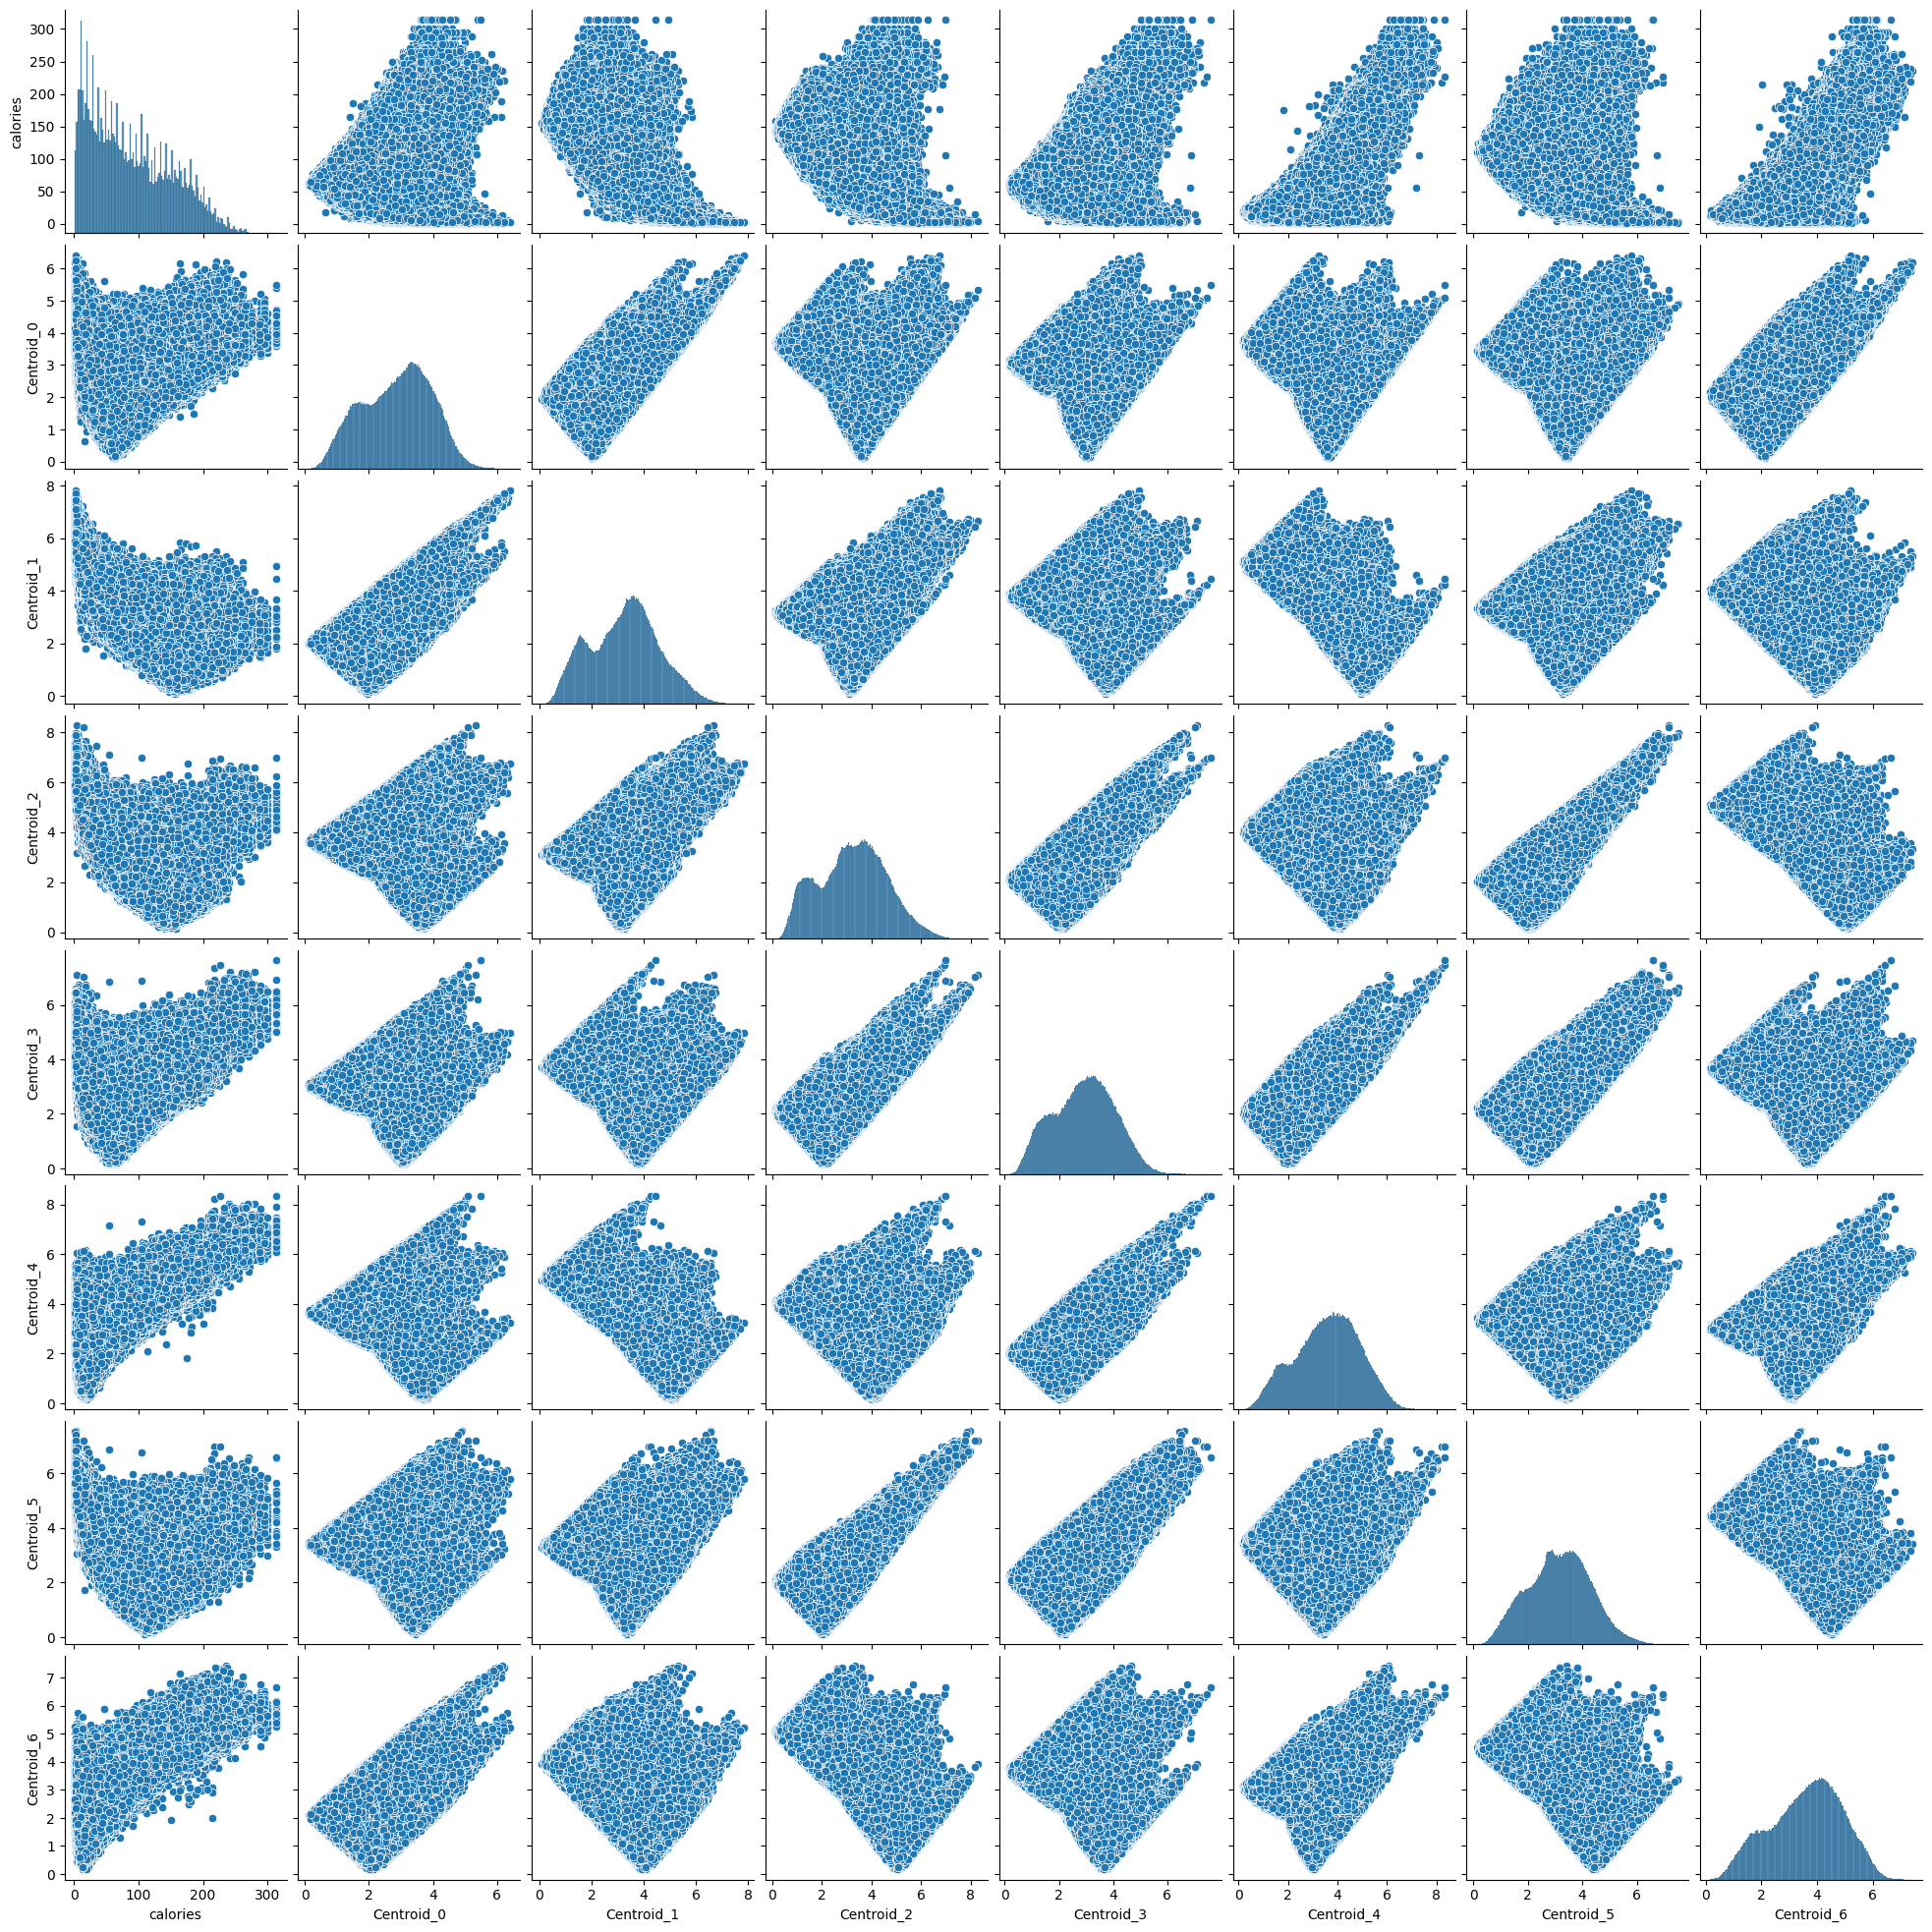

In [ ]:
sns.pairplot(train_cluster[["calories"] + [c for c in train_cluster.columns if c.startswith("Centroid_") ]])

# PCA - unsupervised

Use PCA components instead of features that suffer from multicollinearity

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
def apply_pca(X:pd.DataFrame, standardize=True) \
 -> typing.Tuple[PCA, pd.DataFrame, pd.DataFrame]:
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names, # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

In [ ]:
pca_features = train_1.columns[2:-4]
list(pca_features) + ["male"]

['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp', 'male']

In [ ]:
train_1[list(pca_features) + ["male"]].corrwith(train_1.calories)

,0
age,0.145774
height,-0.003555
weight,0.016333
duration,0.959869
heart_rate,0.908644
body_temp,0.828693
male,0.012192


In [ ]:
def pca_components(df: pd.DataFrame, features: typing.List[str]) \
 -> pd.DataFrame:
  X = df.loc[:, list(features) + ["male"]]
  # loadings are the weights for the original features
  pca, X_pca, loadings = apply_pca(X)
  return pca, X_pca, loadings

In [ ]:
pca, X_pca, loadings = pca_components(train_1, pca_features)

In [ ]:
pca_test, X_test_pca, loadings_test = pca_components(test, pca_features)

In [ ]:
loadings # the weights of the original features in each PC component

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
age,-0.002898,0.040165,0.997605,0.025767,0.010097,0.009710,-0.047984
height,-0.358050,0.460560,-0.037715,-0.499153,0.015144,0.012387,-0.639317
weight,-0.360451,0.476154,0.023143,-0.270539,0.004679,-0.012722,0.754614
duration,0.472495,0.354407,-0.018806,-0.010312,-0.097740,0.800600,0.013049
heart_rate,0.446560,0.349718,-0.018310,0.027633,0.755514,-0.326084,-0.007077
body_temp,0.460836,0.341484,-0.000690,-0.032737,-0.646167,-0.502277,-0.011526
male,-0.326849,0.441623,-0.046226,0.821614,-0.041958,0.004034,-0.138478


In [ ]:
loadings_test

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
age,-0.002886,0.040625,0.997517,0.028014,0.010397,0.009677,-0.048119
height,-0.363074,0.456654,-0.036787,-0.498936,0.019027,0.011097,-0.639428
weight,-0.365970,0.471910,0.023755,-0.270551,0.007829,-0.011991,0.754586
duration,0.468029,0.360448,-0.019223,-0.010578,-0.095080,0.800849,0.012095
heart_rate,0.442925,0.354301,-0.019111,0.033869,0.754115,-0.328690,-0.007062
body_temp,0.456585,0.346935,-0.000644,-0.037463,-0.647632,-0.500231,-0.010170
male,-0.332464,0.437380,-0.048041,0.821229,-0.048085,0.003513,-0.138263


array([<Axes: title={'center': '% Explained Variance'}, xlabel='Component'>,
       <Axes: title={'center': '% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

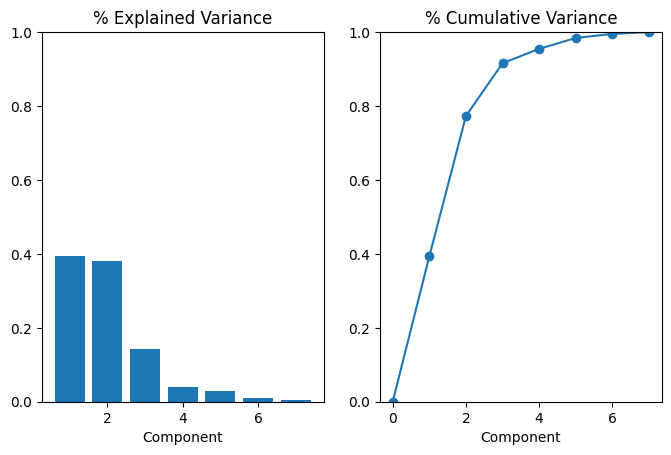

In [ ]:
plot_variance(pca)

array([<Axes: title={'center': '% Explained Variance'}, xlabel='Component'>,
       <Axes: title={'center': '% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

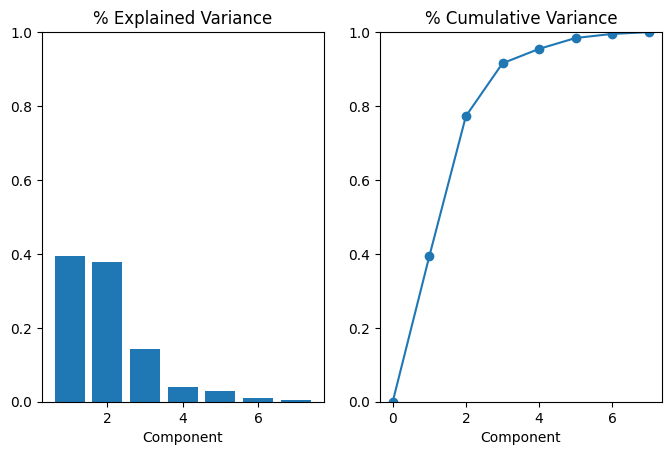

In [ ]:
plot_variance(pca_test)

In [ ]:
train_pca = X_pca.loc[:, ["PC1", "PC2", "PC3", "PC4"] ]
train_pca.loc[:, "id"] = train_1.id.values
train_pca = train_pca.merge(train_1[["id","calories"]], on="id")
train_pca.head()

,PC1,PC2,PC3,PC4,id,calories
0,0.524281,2.249626,-0.468451,0.086835,0,150.0
1,-0.076864,-2.168570,1.576472,-0.040663,1,34.0
2,-0.166362,-2.174147,0.738915,-0.068171,2,29.0
3,0.192247,2.561733,-1.520541,-0.186443,3,140.0
4,2.115667,-0.350741,-0.211032,-0.230042,4,146.0


In [ ]:
test_pca = X_test_pca.loc[:, ["PC1", "PC2", "PC3", "PC4"] ]
test_pca.loc[:, "id"] = test.id.values
test_pca.head()

,PC1,PC2,PC3,PC4,id
0,-1.559127,-0.060007,0.225141,0.619495,750000
1,-0.830165,2.646483,-1.121203,-0.620196,750001
2,0.252125,0.767523,-0.806648,-1.544464,750002
3,1.593316,0.268646,-0.143399,-0.667940,750003
4,0.831599,-0.627017,-0.712382,-0.644055,750004


In [ ]:
train_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   PC1       747159 non-null  float64
 1   PC2       747159 non-null  float64
 2   PC3       747159 non-null  float64
 3   PC4       747159 non-null  float64
 4   id        747159 non-null  int64  
 5   calories  747159 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 34.2 MB


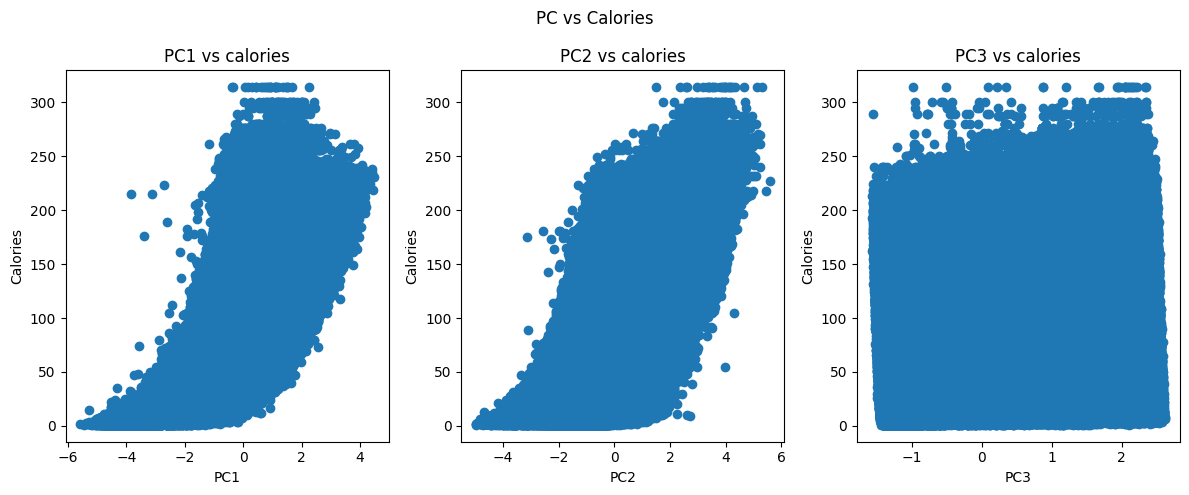

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(12,5))
axes[0].scatter(x = train_pca.PC1 , y = train_pca.calories)
axes[0].set_title('PC1 vs calories')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel("Calories")
axes[1].scatter(x = train_pca.PC2, y = train_pca.calories)
axes[1].set_title('PC2 vs calories')
axes[1].set_xlabel('PC2')
axes[1].set_ylabel('Calories')
axes[2].scatter(x = train_pca.PC3, y = train_pca.calories) # this is basically the age variable
axes[2].set_title('PC3 vs calories')
axes[2].set_xlabel('PC3')
axes[2].set_ylabel('Calories')
fig.suptitle('PC vs Calories')
plt.tight_layout()
plt.show()

In [ ]:
mi_scores = make_mi_scores(train_pca.drop(["id", "calories"], axis=1), train_pca["calories"])
mi_scores

,MI Scores
PC1,0.660130
PC2,0.440945
PC3,0.177376
PC4,0.012887


# Helper Functions

In [ ]:
def get_results(y_true: np.array, y_pred: np.array) -> pd.Series:
  model_mse_d = mean_squared_error(y_true, y_pred)
  r2_score_d = r2_score(y_true, y_pred)
  mean_absolute_error_d = mean_absolute_error(y_true, y_pred)
  root_mean_squared_log_error_d = root_mean_squared_log_error(y_true, y_pred)
  return pd.Series({"mse": model_mse_d, "r2": r2_score_d, "mae": mean_absolute_error_d, "rmlse": np.sqrt(root_mean_squared_log_error_d)}).apply(lambda x: np.round(x,4))

def plot_results(y_true: np.array, y_pred: np.array) -> None:
  plt.scatter(y_true, y_pred)
  plt.xlabel("True Values")
  plt.ylabel("Predicted Values")
  plt.title("True vs Predicted Values")
  plt.plot([0,300], [0, 300], color='red')
  plt.show()

# Create Feature DataSets : combine Clusters with PCA (unsupervised features)

In [ ]:
np.all(train_pca.index == train_1.index), np.all(train_cluster.index == train_1.index)

(np.True_, np.True_)

In [ ]:
train_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 20 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          747159 non-null  int64   
 1   sex         747159 non-null  object  
 2   age         747159 non-null  int64   
 3   height      747159 non-null  float64 
 4   weight      747159 non-null  float64 
 5   duration    747159 non-null  float64 
 6   heart_rate  747159 non-null  float64 
 7   body_temp   747159 non-null  float64 
 8   calories    747159 non-null  float64 
 9   male        747159 non-null  int64   
 10  BMR         747159 non-null  float64 
 11  BMI         747159 non-null  float64 
 12  Cluster     747159 non-null  category
 13  Centroid_0  747159 non-null  float64 
 14  Centroid_1  747159 non-null  float64 
 15  Centroid_2  747159 non-null  float64 
 16  Centroid_3  747159 non-null  float64 
 17  Centroid_4  747159 non-null  float64 
 18  Centroid_5  747159 non-n

In [ ]:
test_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          250000 non-null  int64   
 1   sex         250000 non-null  object  
 2   age         250000 non-null  int64   
 3   height      250000 non-null  float64 
 4   weight      250000 non-null  float64 
 5   duration    250000 non-null  float64 
 6   heart_rate  250000 non-null  float64 
 7   body_temp   250000 non-null  float64 
 8   male        250000 non-null  int64   
 9   BMR         250000 non-null  float64 
 10  BMI         250000 non-null  float64 
 11  Cluster     250000 non-null  category
 12  Centroid_0  250000 non-null  float64 
 13  Centroid_1  250000 non-null  float64 
 14  Centroid_2  250000 non-null  float64 
 15  Centroid_3  250000 non-null  float64 
 16  Centroid_4  250000 non-null  float64 
 17  Centroid_5  250000 non-null  float64 
 18  Centroid_6  250000 non-n

In [ ]:
X_train = train_cluster.merge(train_pca.drop("calories", axis=1), on="id", how="inner")

In [ ]:
X_test = test_cluster.merge(test_pca, on="id", how="inner")

In [ ]:
X_train.shape, train_1.shape

((747159, 24), (747159, 12))

In [ ]:
X_test.shape, test.shape

((250000, 23), (250000, 11))

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          747159 non-null  int64   
 1   sex         747159 non-null  object  
 2   age         747159 non-null  int64   
 3   height      747159 non-null  float64 
 4   weight      747159 non-null  float64 
 5   duration    747159 non-null  float64 
 6   heart_rate  747159 non-null  float64 
 7   body_temp   747159 non-null  float64 
 8   calories    747159 non-null  float64 
 9   male        747159 non-null  int64   
 10  BMR         747159 non-null  float64 
 11  BMI         747159 non-null  float64 
 12  Cluster     747159 non-null  category
 13  Centroid_0  747159 non-null  float64 
 14  Centroid_1  747159 non-null  float64 
 15  Centroid_2  747159 non-null  float64 
 16  Centroid_3  747159 non-null  float64 
 17  Centroid_4  747159 non-null  float64 
 18  Centroid_5  747159 non-n

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          250000 non-null  int64   
 1   sex         250000 non-null  object  
 2   age         250000 non-null  int64   
 3   height      250000 non-null  float64 
 4   weight      250000 non-null  float64 
 5   duration    250000 non-null  float64 
 6   heart_rate  250000 non-null  float64 
 7   body_temp   250000 non-null  float64 
 8   male        250000 non-null  int64   
 9   BMR         250000 non-null  float64 
 10  BMI         250000 non-null  float64 
 11  Cluster     250000 non-null  category
 12  Centroid_0  250000 non-null  float64 
 13  Centroid_1  250000 non-null  float64 
 14  Centroid_2  250000 non-null  float64 
 15  Centroid_3  250000 non-null  float64 
 16  Centroid_4  250000 non-null  float64 
 17  Centroid_5  250000 non-null  float64 
 18  Centroid_6  250000 non-n

# Category Encode

## Effect Encoding for Cluster category

In [ ]:
from category_encoders import SumEncoder

In [ ]:
# the comparison is with the mean of means in Effect encoding
# not with the category that was left out
def effect_encode(df: pd.DataFrame, col: str) -> pd.DataFrame:
    effect_encoder = SumEncoder(cols=[col], verbose=False)
    df_genre_encoded = effect_encoder.fit_transform(df[[col]])
    return df_genre_encoded

In [ ]:
effect_encode_cluster_train = effect_encode(X_train, "Cluster")
effect_encode_cluster_train

,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5
0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...
747154,1.0,0.0,0.0,0.0,0.0,0.0
747155,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
747156,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
747157,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
effect_encode_cluster_test = effect_encode(X_test, "Cluster")
effect_encode_cluster_test

,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5
0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...
249995,0.0,0.0,0.0,0.0,1.0,0.0
249996,0.0,0.0,0.0,0.0,0.0,1.0
249997,0.0,0.0,0.0,1.0,0.0,0.0
249998,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


## Target Encoding For Cluster catetegory

In [ ]:
from category_encoders import MEstimateEncoder # QuantileEncoder
from sklearn.model_selection import KFold

In [ ]:
# target_encoding for categorical variables with high cardinality
class CrossFoldEncoder:
    def __init__(self, encoder, **kwargs):
        self.encoder_ = encoder
        self.kwargs_ = kwargs  # keyword arguments for the encoder
        self.cv_ = KFold(n_splits=5)

    # Fit an encoder on one split and transform the feature on the
    # other. Iterating over the splits in all folds gives a complete
    # transformation.
    # We also now have one trained encoder on EACH fold.
    def fit_transform(self, X, y, cols):
        # we hav one trained encoder on EACH fold.
        self.fitted_encoders_ = []
        self.cols_ = cols
        X_encoded = []
        for idx_encode, idx_train in self.cv_.split(X):
            fitted_encoder = self.encoder_(cols=cols, **self.kwargs_)
            fitted_encoder.fit(
                X.iloc[idx_encode, :], y.iloc[idx_encode],
            )
            X_encoded.append(fitted_encoder.transform(X.iloc[idx_train, :])[cols])
            self.fitted_encoders_.append(fitted_encoder)
        X_encoded = pd.concat(X_encoded)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

    # To transform the test data, average the encodings learned from
    # each fold.
    def transform(self, X):
        from functools import reduce

        X_encoded_list = []
        for fitted_encoder in self.fitted_encoders_:
            X_encoded = fitted_encoder.transform(X)
            X_encoded_list.append(X_encoded[self.cols_])
        X_encoded = reduce(
            lambda x, y: x.add(y, fill_value=0), X_encoded_list
        ) / len(X_encoded_list)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

In [ ]:
target_encode_train = X_train[["id", "Cluster", "calories"]].copy()
target_encode_test = X_test[["id", "Cluster"]].copy()
target_encode_train.loc[:, "Cluster_encoded"] = 0.0
target_encode_test.loc[:, "Cluster_encoded"] = 0.0

In [ ]:
print(target_encode_train.loc[X_train.male == 0, :].shape, target_encode_train.loc[X_train.male == 1, :].shape)
X_train.value_counts("male")

(374290, 4) (372869, 4)


,count
male,
0,374290
1,372869


In [ ]:
target_encoder_m = CrossFoldEncoder(MEstimateEncoder, m=5)
target_encoder_f = CrossFoldEncoder(MEstimateEncoder, m=5)

target_encode_train.loc[X_train.male == 1, "Cluster_encoded"] = \
target_encoder_m.fit_transform(X_train[X_train.male == 1]\
                               .drop(columns=['calories']),
                               X_train[X_train.male == 1].calories, ["Cluster"])
target_encode_train.loc[X_train.male == 0, "Cluster_encoded"] = \
target_encoder_f.fit_transform(X_train[X_train.male == 0]\
                               .drop(columns=['calories']),
                               X_train[X_train.male == 0].calories, ["Cluster"])

target_encode_test.loc[X_test.male == 1, "Cluster_encoded"] = \
target_encoder_m.transform(X_test[X_test.male == 1])
target_encode_test.loc[X_test.male == 0, "Cluster_encoded"] = \
target_encoder_f.transform(X_test[X_test.male == 0])

In [ ]:
target_encode_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   id               747159 non-null  int64   
 1   Cluster          747159 non-null  category
 2   calories         747159 non-null  float64 
 3   Cluster_encoded  747159 non-null  float64 
dtypes: category(1), float64(2), int64(1)
memory usage: 17.8 MB


In [ ]:
target_encode_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   id               250000 non-null  int64   
 1   Cluster          250000 non-null  category
 2   Cluster_encoded  250000 non-null  float64 
dtypes: category(1), float64(1), int64(1)
memory usage: 4.1 MB


<Axes: xlabel='Cluster_encoded', ylabel='calories'>

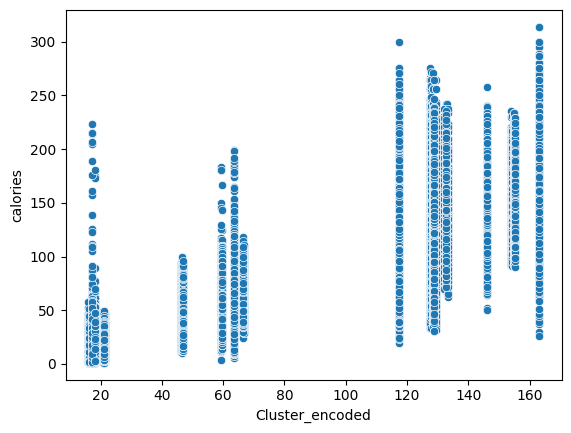

In [ ]:
sns.scatterplot(x=target_encode_train.Cluster_encoded, y= target_encode_train.calories)

# Multiple Linear Regression

In [ ]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression

In [ ]:
def check_multicollinearity(df: pd.DataFrame, cols = typing.List[str]) -> pd.DataFrame:

  # Create a subset of the data with the continous independent variables.
  X_vif = df[cols]

  # Calculate the variance inflation factor for each variable.
  vif = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

  # Create a DataFrame with the VIF results for the column names in X_vif.
  df_vif = pd.DataFrame(vif, index=X_vif.columns, columns = ['VIF'])

  # Display the VIF results.
  return df_vif

In [ ]:
def create_ols_dataframes(y_true: np.array, y_pred: np.array) -> pd.DataFrame:
    residuals = y_true - y_pred
    return pd.DataFrame({"y_true": y_true, "y_pred": y_pred, \
                         "residuals": residuals})

def create_residual_plots(y_true: np.array, y_pred: np.array) -> None:
  residuals = y_true - y_pred
  fig, axes = plt.subplots(1,3,figsize=(12,5))
  axes[0].scatter(y_pred, residuals)
  axes[0].hlines(y=0, xmin = y_pred.min(), xmax=y_pred.max(), color='red')
  axes[0].set_xlabel("Fitted Values")
  axes[0].set_ylabel("Residuals")
  axes[0].set_title("Heteroscedasticity Plot")
  axes[1].hist(residuals)
  axes[1].set_xlabel("Residuals")
  axes[1].set_ylabel("Frequency")
  axes[1].set_title("Normal Distribution of Residuals")
  sm.qqplot(residuals, line='s', ax=axes[2])
  axes[2].set_title("Q-Q Plot")
  plt.tight_layout()
  plt.title("Residual Plot")
  plt.show()

## Create Sets for Linear Regression

In [ ]:
centroid_dist = [c for c in X_train.columns if c.startswith('Centroid_')]
pca_components = ['PC1', 'PC2', 'PC3'] #PC3 is basically the age variable

In [ ]:
# by default join uses Other's index
X_train_lr = effect_encode_cluster_train.join(X_train[["male", "duration", "heart_rate", "BMR", "BMI", "id"] + centroid_dist + pca_components])
y_lr = X_train.calories
# sanity check
np.all(X_train_lr.index == train_1.index), np.all(y_lr.index == train_1.index),  X_train_lr.shape, y_lr.shape

(np.True_, np.True_, (747159, 22), (747159,))

In [ ]:
X_test_lr = effect_encode_cluster_test.join(X_test[["male", "duration", "heart_rate", "BMR", "BMI", "id"] + centroid_dist + pca_components])
# sanity check
np.all(X_test_lr.index == test.index)

np.True_

In [ ]:
X_train_lr = X_train_lr.merge(target_encode_train[["id", "Cluster_encoded"]], on="id")
X_test_lr = X_test_lr.merge(target_encode_test[["id", "Cluster_encoded"]], on="id")

In [ ]:
X_train_lr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Cluster_0        747159 non-null  float64
 1   Cluster_1        747159 non-null  float64
 2   Cluster_2        747159 non-null  float64
 3   Cluster_3        747159 non-null  float64
 4   Cluster_4        747159 non-null  float64
 5   Cluster_5        747159 non-null  float64
 6   male             747159 non-null  int64  
 7   duration         747159 non-null  float64
 8   heart_rate       747159 non-null  float64
 9   BMR              747159 non-null  float64
 10  BMI              747159 non-null  float64
 11  id               747159 non-null  int64  
 12  Centroid_0       747159 non-null  float64
 13  Centroid_1       747159 non-null  float64
 14  Centroid_2       747159 non-null  float64
 15  Centroid_3       747159 non-null  float64
 16  Centroid_4       747159 non-null  floa

In [ ]:
X_test_lr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Cluster_0        250000 non-null  float64
 1   Cluster_1        250000 non-null  float64
 2   Cluster_2        250000 non-null  float64
 3   Cluster_3        250000 non-null  float64
 4   Cluster_4        250000 non-null  float64
 5   Cluster_5        250000 non-null  float64
 6   male             250000 non-null  int64  
 7   duration         250000 non-null  float64
 8   heart_rate       250000 non-null  float64
 9   BMR              250000 non-null  float64
 10  BMI              250000 non-null  float64
 11  id               250000 non-null  int64  
 12  Centroid_0       250000 non-null  float64
 13  Centroid_1       250000 non-null  float64
 14  Centroid_2       250000 non-null  float64
 15  Centroid_3       250000 non-null  float64
 16  Centroid_4       250000 non-null  floa

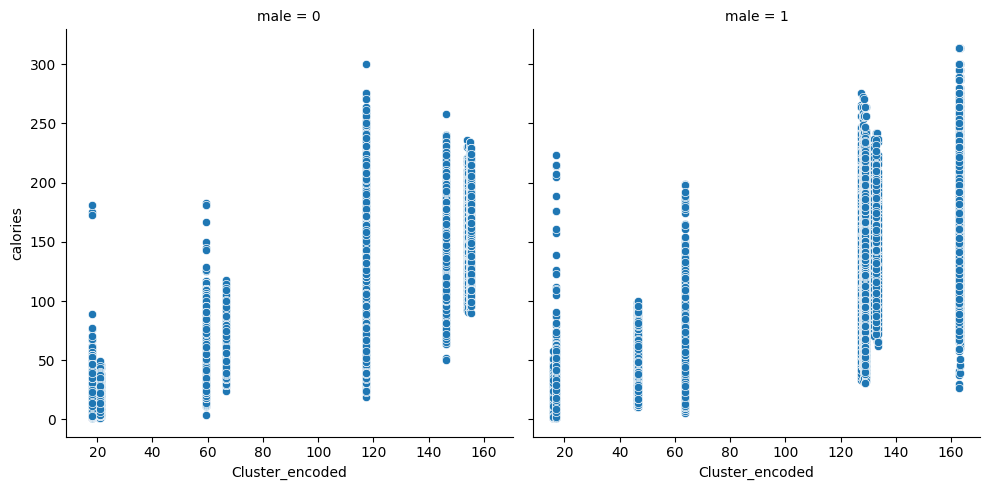

In [ ]:
sns.relplot(x=X_train_lr.Cluster_encoded, y= y_lr, col=X_train_lr.male)

In [ ]:
np.all(X_train_lr.index == train_1.index), np.all(y_lr.index == train_1.index),  X_train_lr.shape, y_lr.shape

(np.True_, np.True_, (747159, 23), (747159,))

In [ ]:
np.all(X_test_lr.index == test.index)

np.True_

###  Interaction Features

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
cluster_cols = [c for c in effect_encode_cluster_train if c.startswith('Cluster')]
cluster_cols

['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4', 'Cluster_5']

In [ ]:
inter_df_train = X_train_lr[["male"] + cluster_cols].copy()
inter_df_test = X_test_lr[["male"] + cluster_cols].copy()

In [ ]:
poly = PolynomialFeatures(degree = 1, include_bias=False, interaction_only=True)
cluster_sex_interactions_train = pd.DataFrame()
cluster_sex_interactions_test = pd.DataFrame()
for c in cluster_cols:
  cluster_sex_interactions_train[f'male_{c}'] = poly.fit_transform(inter_df_train[["male", c]])[:,1]
  cluster_sex_interactions_test[f'male_{c}'] = poly.fit_transform(inter_df_test[["male", c]])[:,1]
  # cluster_sex_interactions_train[f'male_{c}'] = inter_df_train[c].mul(inter_df_train["male"])
  # cluster_sex_interactions_test[f'male_{c}'] = inter_df_test[c].mul(inter_df_test["male"])

In [ ]:
cluster_sex_interactions_train

,male_Cluster_0,male_Cluster_1,male_Cluster_2,male_Cluster_3,male_Cluster_4,male_Cluster_5
0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...
747154,1.0,0.0,0.0,0.0,0.0,0.0
747155,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
747156,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
747157,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
cluster_sex_interactions_test

,male_Cluster_0,male_Cluster_1,male_Cluster_2,male_Cluster_3,male_Cluster_4,male_Cluster_5
0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...
249995,0.0,0.0,0.0,0.0,1.0,0.0
249996,0.0,0.0,0.0,0.0,0.0,1.0
249997,0.0,0.0,0.0,1.0,0.0,0.0
249998,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [ ]:
X_train_lr = pd.concat([X_train_lr, cluster_sex_interactions_train], axis=1)
X_test_lr = pd.concat([X_test_lr, cluster_sex_interactions_test], axis=1)

In [ ]:
X_test_lr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Cluster_0        250000 non-null  float64
 1   Cluster_1        250000 non-null  float64
 2   Cluster_2        250000 non-null  float64
 3   Cluster_3        250000 non-null  float64
 4   Cluster_4        250000 non-null  float64
 5   Cluster_5        250000 non-null  float64
 6   male             250000 non-null  int64  
 7   duration         250000 non-null  float64
 8   heart_rate       250000 non-null  float64
 9   BMR              250000 non-null  float64
 10  BMI              250000 non-null  float64
 11  id               250000 non-null  int64  
 12  Centroid_0       250000 non-null  float64
 13  Centroid_1       250000 non-null  float64
 14  Centroid_2       250000 non-null  float64
 15  Centroid_3       250000 non-null  float64
 16  Centroid_4       250000 non-null  floa

In [ ]:
male_cluster_cols = [c for c in X_train_lr.columns if c.startswith('male_Cluster')]
male_cluster_cols

['male_Cluster_0',
 'male_Cluster_1',
 'male_Cluster_2',
 'male_Cluster_3',
 'male_Cluster_4',
 'male_Cluster_5']

In [ ]:
pca_cols = [col for col in X_train_lr.columns if col.startswith("PC")]
pca_cols

['PC1', 'PC2', 'PC3']

In [ ]:
cluster_cols

['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4', 'Cluster_5']

## Base Method

In [ ]:
ols_features = ' + '.join(["heart_rate"]  + pca_cols + cluster_cols)
ols_features

'heart_rate + PC1 + PC2 + PC3 + Cluster_0 + Cluster_1 + Cluster_2 + Cluster_3 + Cluster_4 + Cluster_5'

In [ ]:
check_multicollinearity(X_train_lr, ["heart_rate"]  + pca_cols + cluster_cols)

,VIF
heart_rate,1.173641
PC1,6.126525
PC2,5.810412
PC3,1.395240
Cluster_0,5.808408
Cluster_1,4.930242
Cluster_2,4.591819
Cluster_3,3.298291
Cluster_4,5.583436
Cluster_5,2.609954


use only linear features or category encoded features

In [ ]:
ols_formula = f'calories ~ {" + ".join(["duration", "PC1", "PC2"]  + cluster_cols)}'
ols_formula

'calories ~ duration + PC1 + PC2 + Cluster_0 + Cluster_1 + Cluster_2 + Cluster_3 + Cluster_4 + Cluster_5'

In [ ]:
X_train_ols = X_train_lr[["duration", "PC1", "PC2"] + cluster_cols].copy()
y_ols = y_lr.copy().apply(lambda x: np.log(x))
X_train_ols = X_train_ols - X_train_ols.mean()
x_train_ols = X_train_ols / X_train_ols.std()

In [ ]:
OLS = ols(formula = ols_formula, data = pd.concat([X_train_ols, y_ols], axis=1))
model = OLS.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               calories   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 1.632e+06
Date:                Mon, 02 Jun 2025   Prob (F-statistic):               0.00
Time:                        08:21:55   Log-Likelihood:                 69396.
No. Observations:              747159   AIC:                        -1.388e+05
Df Residuals:                  747149   BIC:                        -1.387e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.1128      0.000   1.61e+04      0.000       4.112       4.113
duration      -0.0069      0.000    -47.950      0.000      -0.007      -0.007
PC1            0.4822      0.001    729.738      0.000       0.481       0.483
PC2            0.3913      0.001    707.251      0.000       0.390       0.392
Cluster_0     -0.0940      0.001    -83.432      0.000      -0.096      -0.092
Cluster_1     -0.0021      0.001     -1.772      0.076      -0.004       0.000
Cluster_2     -0.0726      0.001    -67.932      0.000      -0.075      -0.071
Cluster_3      0.0761      0.001     89.315      0.000       0.074       0.078
Cluster_4     -0.2036      0.001   -164.585      0.000      -0.206      -0.201
Cluster_5      0.1830      0.001    223.229      0.000       0.181       0.185
==============================================================================
Omnibus:                   176347.677   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1059195.936
Skew:                          -1.003   Prob(JB):                         0.00
Kurtosis:                       8.477   Cond. No.                         57.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

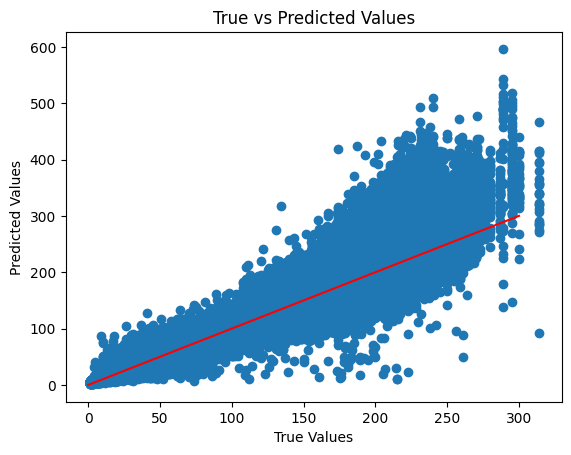

In [ ]:
#transform prediction back to original to compare originals (not transformed)
ols_predict = model.predict(X_train_ols)
ols_predict = ols_predict.apply(np.expm1)
plot_results(y_lr, ols_predict)

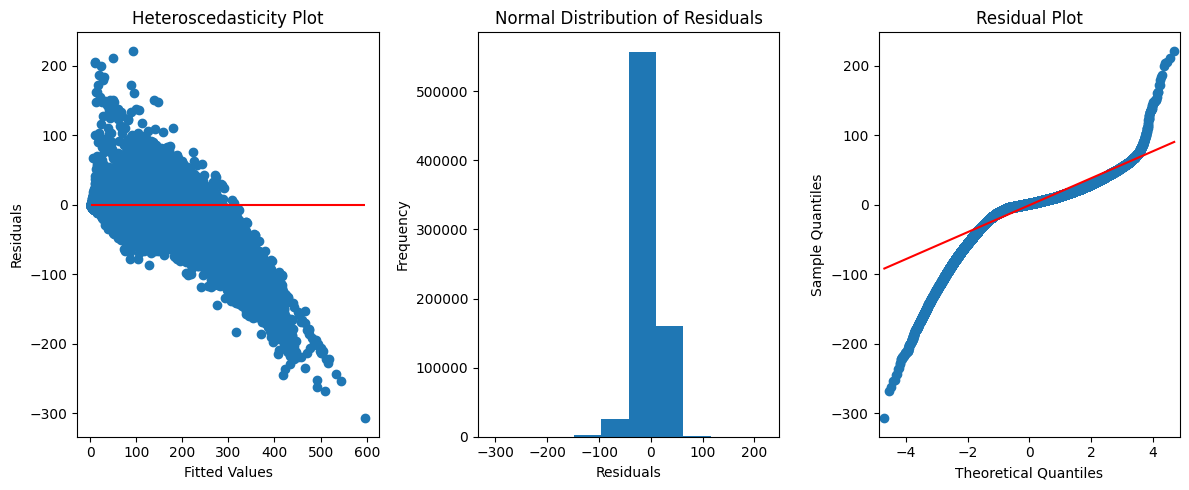

In [ ]:
create_residual_plots(y_lr, ols_predict)

In [ ]:
np.round(np.mean(model.resid),4)

np.float64(0.0)

## Split training sets

In [ ]:
X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(X_train_lr, y_lr, test_size=0.2, random_state=42)

## Ridge Regression

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.compose import TransformedTargetRegressor

In [ ]:
ridge_features = cluster_cols + centroid_dist + pca_components
ridge_features = ridge_features[:-1] # Remove non-linear PC3
ridge_features = ["male", "duration", "heart_rate"] + ridge_features
X_lr_train[ridge_features]

,male,duration,heart_rate,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Centroid_0,Centroid_1,Centroid_2,Centroid_3,Centroid_4,Centroid_5,Centroid_6,PC1,PC2
258035,0,8.0,89.0,0.0,1.0,0.0,0.0,0.0,0.0,3.377352,4.593981,3.553904,1.768252,0.749840,3.065156,2.973728,-0.684126,-2.128486
504754,0,25.0,107.0,0.0,0.0,1.0,0.0,0.0,0.0,3.272029,2.479834,1.115656,2.545480,4.253396,1.824231,4.823761,1.959034,0.478973
58035,0,8.0,88.0,0.0,0.0,0.0,0.0,0.0,1.0,3.167166,4.320475,3.042592,1.028105,1.164729,2.827204,3.190992,-0.266818,-1.940881
535525,0,7.0,88.0,0.0,0.0,0.0,0.0,0.0,1.0,3.435204,4.508268,3.000872,0.976762,1.330447,2.752472,3.539577,0.020270,-2.182276
274472,1,29.0,101.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.440160,3.859706,3.171923,3.897687,5.072102,2.673243,5.672347,2.330110,0.076510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,1,29.0,112.0,1.0,0.0,0.0,0.0,0.0,0.0,2.947195,1.240112,3.812087,4.714317,5.986637,4.296081,4.802015,0.647332,3.165357
365838,1,2.0,81.0,0.0,0.0,0.0,0.0,1.0,0.0,3.355743,5.113019,5.694042,4.110660,2.794939,4.840727,1.525919,-3.133344,-1.204306
131932,0,28.0,103.0,0.0,0.0,1.0,0.0,0.0,0.0,4.153943,3.599933,0.841368,2.449130,4.248335,2.033433,5.486590,2.690417,-0.530371
671155,1,18.0,99.0,1.0,0.0,0.0,0.0,0.0,0.0,1.867457,1.800481,4.396701,4.435382,5.295607,4.429247,3.514495,-0.946195,2.684330


### Standardize

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler

In [ ]:
# use RobustScaler because we have outliers
scaler = RobustScaler().fit(X_lr_train.copy()[ridge_features])
X_lr_train_scaled = scaler.transform(X_lr_train.copy()[ridge_features])
print('X_lr_train_scaled:', X_lr_train_scaled)

X_lr_train_scaled: [[ 0.         -0.46666667 -0.4        ... -0.40652323 -0.32122023
  -0.85720603]
 [ 0.          0.66666667  0.8        ...  0.58933971  0.78403539
   0.21802877]
 [ 0.         -0.46666667 -0.46666667 ... -0.28957117 -0.14672002
  -0.77984396]
 ...
 [ 0.          0.86666667  0.53333333 ...  0.9461364   1.0898683
  -0.19819325]
 [ 1.          0.2         0.26666667 ... -0.11543137 -0.43080625
   1.12744897]
 [ 0.         -0.26666667  0.26666667 ...  0.14354193  0.36053825
  -0.5240422 ]]


### transform the target using np.log

In [ ]:
from sklearn.pipeline import make_pipeline

In [ ]:
# since we are transforming the target use neg_root_means_squared_error
# instead of neg_root_mean_squared_log_error
#regressor = RidgeCV(alphas=[0.1,1.0,10.0], scoring='neg_root_mean_squared_log_error')
regressor = RidgeCV(alphas=[0.1,1.0,10.0], scoring='neg_root_mean_squared_error')

transformedRegressor = TransformedTargetRegressor(
      regressor= regressor,
      func=np.log1p,
      inverse_func=np.expm1
)
pipe = make_pipeline(
    #PowerTransformer(method='yeo-johnson', standardize=False),\
    transformedRegressor)
clf = pipe.fit(X_lr_train_scaled, y_lr_train)

In [ ]:
clf.score(X_lr_train_scaled, y_lr_train)

0.9546559264544481

In [ ]:
pd.Series([-transformedRegressor.regressor_.best_score_, transformedRegressor.regressor_.alpha_], index=["best root mean squared log error", "best alpha"], name="best values")

,best values
best root mean squared log error,0.151469
best alpha,0.100000


In [ ]:
y_lr_predict_train = clf.predict(X_lr_train_scaled)
get_results(y_lr_train, y_lr_predict_train)

,0
mse,176.7108
r2,0.9547
mae,8.5002
rmlse,0.3892


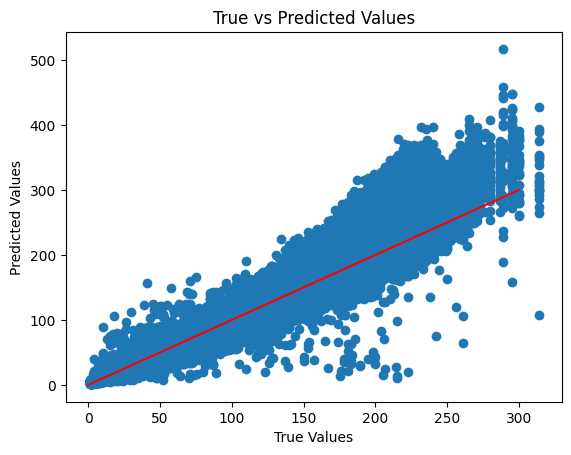

In [ ]:
plot_results(y_lr_train, y_lr_predict_train)

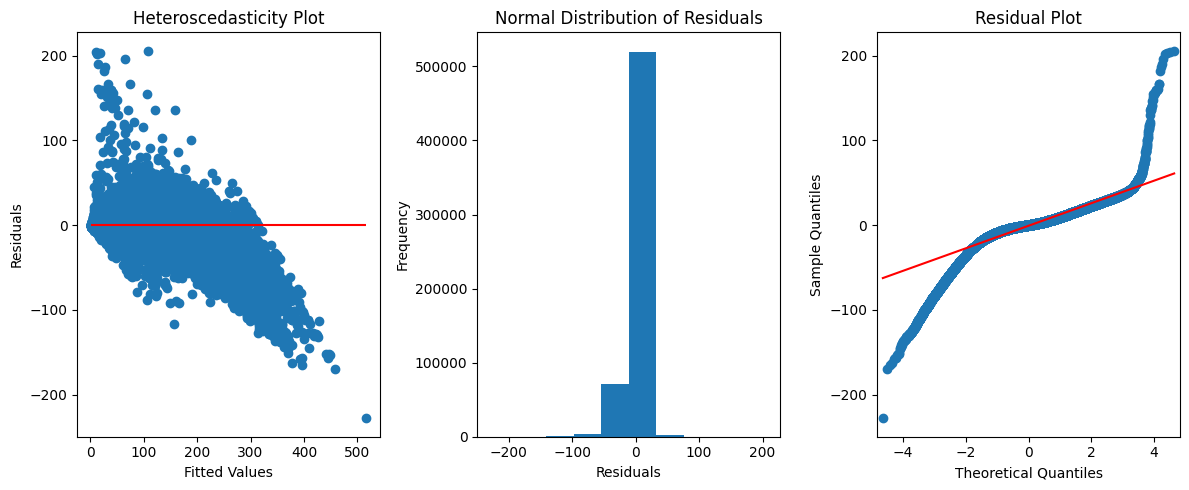

In [ ]:
create_residual_plots(y_lr_train, y_lr_predict_train)

In [ ]:
lr_resid_train = y_lr_train - y_lr_predict_train
np.mean(lr_resid_train)

np.float64(-0.647955130441853)

### check on the validation set

In [ ]:
X_lr_test_scaled = scaler.transform(X_lr_test.copy()[ridge_features])

In [ ]:
clf.score(X_lr_test_scaled, y_lr_test)

0.9550253174498232

In [ ]:
y_lr_predict_test = clf.predict(X_lr_test_scaled)

In [ ]:
get_results(y_lr_test, y_lr_predict_test)

,0
mse,174.4621
r2,0.9550
mae,8.4838
rmlse,0.3898


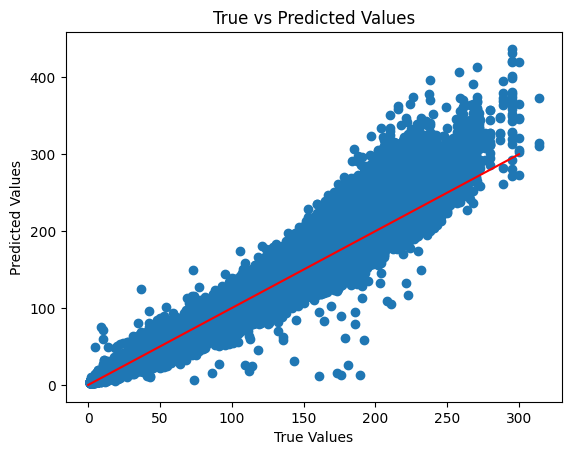

In [ ]:
plot_results(y_lr_test, y_lr_predict_test)

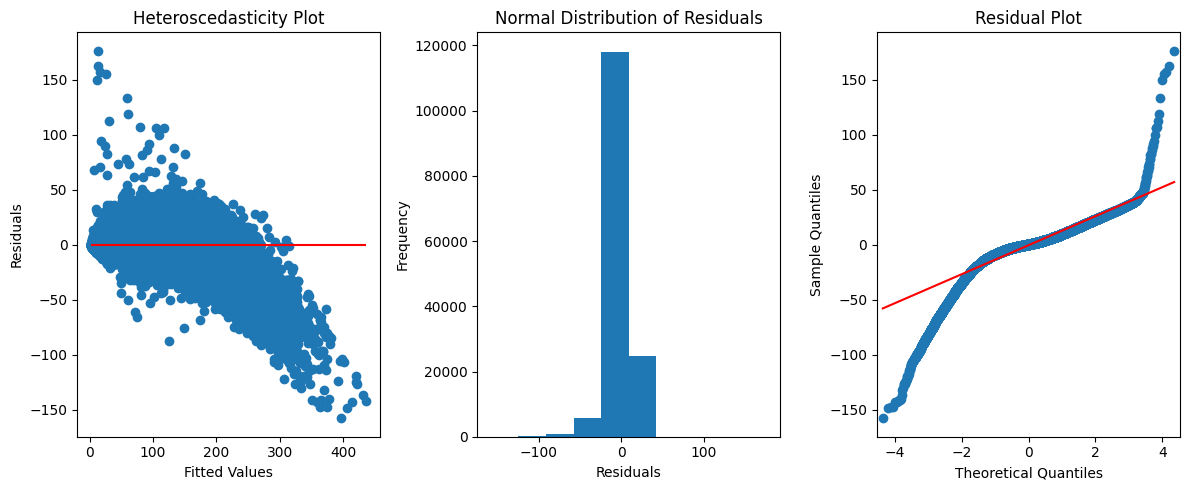

In [ ]:
create_residual_plots(y_lr_test, y_lr_predict_test)

In [ ]:
val_resid_train = y_lr_test - y_lr_predict_test
np.mean(val_resid_train)

np.float64(-0.6207884899170909)

In [ ]:
coefficients = transformedRegressor.regressor_.coef_
pd.DataFrame(coefficients, index=X_lr_test[ridge_features].columns, columns=["coefficient"]).sort_values(by="coefficient", ascending=False)


,coefficient
PC1,1.040465
PC2,0.916344
Centroid_2,0.622615
duration,0.335178
Centroid_1,0.257843
Cluster_2,0.121644
Centroid_6,0.110121
Centroid_4,0.098649
Cluster_0,0.034244
Cluster_5,0.017426


## SGD

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
scaler = RobustScaler().fit(X_lr_train.copy()[ridge_features])
X_lr_train_scaled = scaler.transform(X_lr_train.copy()[ridge_features])

In [ ]:
sgdregressor = SGDRegressor(max_iter=1000, tol=1e-3, random_state = 42)
transformedSGD = TransformedTargetRegressor(
      regressor= sgdregressor,
      func=np.log1p,
      inverse_func=np.expm1
)
pipe = make_pipeline(
    #PowerTransformer(method='yeo-johnson', standardize=False),\
    transformedSGD
    )
clf = pipe.fit(X_lr_train_scaled, y_lr_train)

In [ ]:
clf.score(X_lr_train_scaled, y_lr_train)

0.9556376742525408

In [ ]:
y_lr_predict_train = clf.predict(X_lr_train_scaled)

In [ ]:
get_results(y_lr_train, y_lr_predict_train)

,0
mse,172.8848
r2,0.9556
mae,8.4474
rmlse,0.3893


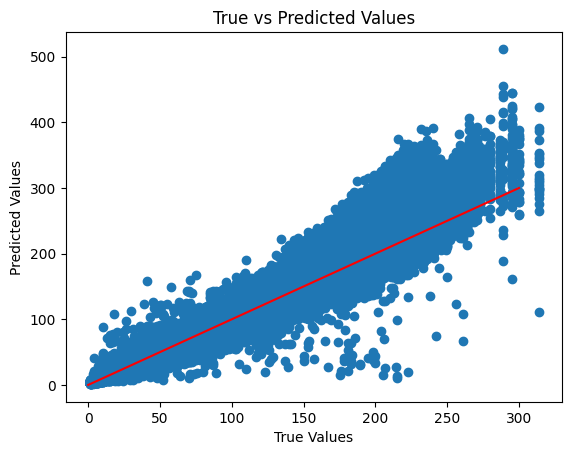

In [ ]:
plot_results(y_lr_train, y_lr_predict_train)

### check on Validation set

In [ ]:
X_lr_test_scaled = scaler.transform(X_lr_test.copy()[ridge_features])

In [ ]:
clf.score(X_lr_test_scaled, y_lr_test)

0.9559788812472282

In [ ]:
y_lr_predict_test = clf.predict(X_lr_test_scaled)

In [ ]:
get_results(y_lr_test, y_lr_predict_test)

,0
mse,170.7631
r2,0.9560
mae,8.4318
rmlse,0.3898


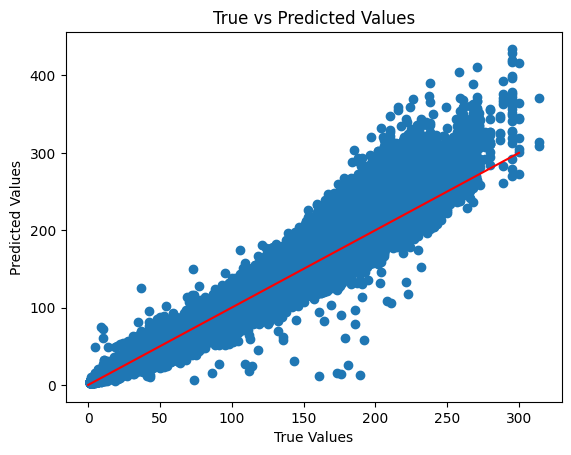

In [ ]:
plot_results(y_lr_test, y_lr_predict_test)

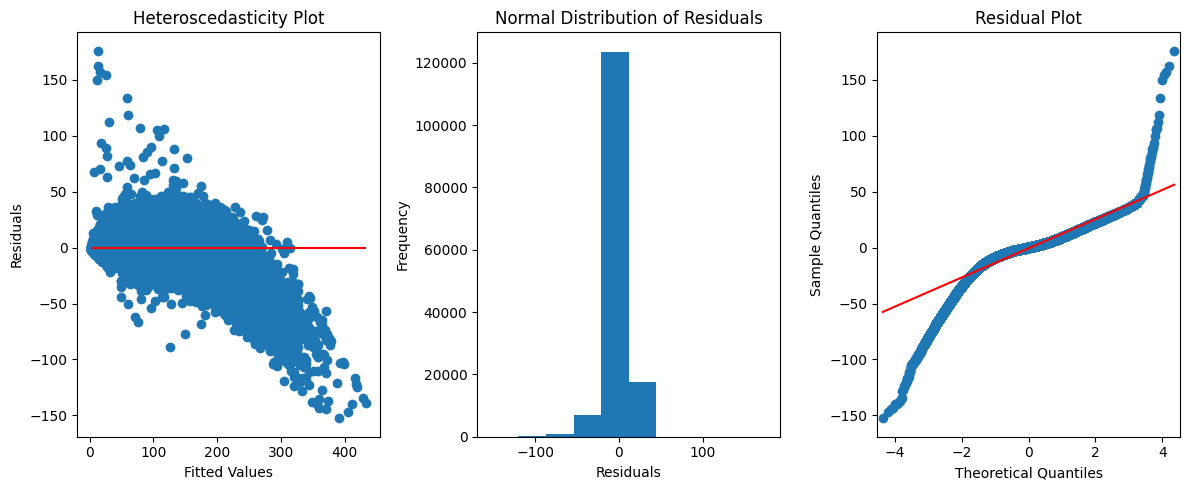

In [ ]:
create_residual_plots(y_lr_test, y_lr_predict_test)

In [ ]:
np.mean(y_lr_test - y_lr_predict_test)

np.float64(-0.6518572965931201)

In [ ]:
 pd.DataFrame(transformedSGD.regressor_.coef_, index=X_lr_test[ridge_features].columns, columns=["coefficient"]).sort_values(by="coefficient", ascending=False)

,coefficient
PC1,0.994812
PC2,0.898439
Centroid_2,0.605349
duration,0.356785
Centroid_1,0.269733
Centroid_6,0.136000
Cluster_2,0.117805
Centroid_4,0.092503
Cluster_0,0.034296
Cluster_5,0.019702


# TREES

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor

## prepare tree features

In [ ]:
X_train_tree = X_train.copy()
y_train_tree = X_train_tree.pop("calories")

In [ ]:
X_test_tree = X_test.copy()

In [ ]:
X_train_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          747159 non-null  int64   
 1   sex         747159 non-null  object  
 2   age         747159 non-null  int64   
 3   height      747159 non-null  float64 
 4   weight      747159 non-null  float64 
 5   duration    747159 non-null  float64 
 6   heart_rate  747159 non-null  float64 
 7   body_temp   747159 non-null  float64 
 8   male        747159 non-null  int64   
 9   BMR         747159 non-null  float64 
 10  BMI         747159 non-null  float64 
 11  Cluster     747159 non-null  category
 12  Centroid_0  747159 non-null  float64 
 13  Centroid_1  747159 non-null  float64 
 14  Centroid_2  747159 non-null  float64 
 15  Centroid_3  747159 non-null  float64 
 16  Centroid_4  747159 non-null  float64 
 17  Centroid_5  747159 non-null  float64 
 18  Centroid_6  747159 non-n

In [ ]:
X_test_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id          250000 non-null  int64   
 1   sex         250000 non-null  object  
 2   age         250000 non-null  int64   
 3   height      250000 non-null  float64 
 4   weight      250000 non-null  float64 
 5   duration    250000 non-null  float64 
 6   heart_rate  250000 non-null  float64 
 7   body_temp   250000 non-null  float64 
 8   male        250000 non-null  int64   
 9   BMR         250000 non-null  float64 
 10  BMI         250000 non-null  float64 
 11  Cluster     250000 non-null  category
 12  Centroid_0  250000 non-null  float64 
 13  Centroid_1  250000 non-null  float64 
 14  Centroid_2  250000 non-null  float64 
 15  Centroid_3  250000 non-null  float64 
 16  Centroid_4  250000 non-null  float64 
 17  Centroid_5  250000 non-null  float64 
 18  Centroid_6  250000 non-n

In [ ]:
def create_tree_feature(df:pd.DataFrame) -> pd.DataFrame:
  X = df[["id"]].copy()
  X.loc[:,"bmi_by_sex"] = df.BMI.mul(df.male)
  X.loc[:,"duration_by_sex"] = df.duration.mul(df.male)
  X.loc[:,"hear_rate_by_sex"] = df.heart_rate.mul(df.male)

  # X.loc[:,"bmi_by_age"] = df.BMI.mul(df.age)
  # X.loc[:,"duration_by_age"] = df.duration.mul(df.age)
  # X.loc[:,"hear_rate_by_age"] = df.heart_rate.mul(df.age)
  return X[["id","duration_by_sex","hear_rate_by_sex", "bmi_by_sex"]]

In [ ]:
tree_features_train = create_tree_feature(X_train_tree)
tree_features_test = create_tree_feature(X_test_tree)

In [ ]:
X_train_tree = X_train_tree.merge(tree_features_train, on="id", how="inner")
X_test_tree = X_test_tree.merge(tree_features_test, on="id", how="inner")

In [ ]:
X_train_tree = X_train_tree.merge(target_encode_train[["id", "Cluster_encoded"]], on="id", how="inner")
X_test_tree = X_test_tree.merge(target_encode_test[["id", "Cluster_encoded"]], on="id", how="inner")

### use male encoded as category

In [ ]:
X_train_tree["male"] = X_train_tree["male"].astype("category")
X_test_tree["male"] = X_test_tree["male"].astype("category")

In [ ]:
X_train_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747159 entries, 0 to 747158
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id                747159 non-null  int64   
 1   sex               747159 non-null  object  
 2   age               747159 non-null  int64   
 3   height            747159 non-null  float64 
 4   weight            747159 non-null  float64 
 5   duration          747159 non-null  float64 
 6   heart_rate        747159 non-null  float64 
 7   body_temp         747159 non-null  float64 
 8   male              747159 non-null  category
 9   BMR               747159 non-null  float64 
 10  BMI               747159 non-null  float64 
 11  Cluster           747159 non-null  category
 12  Centroid_0        747159 non-null  float64 
 13  Centroid_1        747159 non-null  float64 
 14  Centroid_2        747159 non-null  float64 
 15  Centroid_3        747159 non-null  float64 
 16  Ce

In [ ]:
X_test_tree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id                250000 non-null  int64   
 1   sex               250000 non-null  object  
 2   age               250000 non-null  int64   
 3   height            250000 non-null  float64 
 4   weight            250000 non-null  float64 
 5   duration          250000 non-null  float64 
 6   heart_rate        250000 non-null  float64 
 7   body_temp         250000 non-null  float64 
 8   male              250000 non-null  category
 9   BMR               250000 non-null  float64 
 10  BMI               250000 non-null  float64 
 11  Cluster           250000 non-null  category
 12  Centroid_0        250000 non-null  float64 
 13  Centroid_1        250000 non-null  float64 
 14  Centroid_2        250000 non-null  float64 
 15  Centroid_3        250000 non-null  float64 
 16  Ce

In [ ]:
np.all(X_train_tree.index == X_train.index),np.all(X_test_tree.index == X_test.index)

(np.True_, np.True_)

In [ ]:
centroid_dist = [c for c in X_train.columns if c.startswith('Centroid_')]
pca_components = ['PC1', 'PC2', 'PC3', 'PC4'] #PC3 is basically the age variable

In [ ]:
tree_features = pca_components  + centroid_dist + ["male", "age", "duration", \
                                                   "heart_rate", "body_temp",\
                                                   "BMR", "BMI",\
                                                   "duration_by_sex",
                                                   "hear_rate_by_sex",
                                                   "bmi_by_sex",
                                                   "bmi_by_sex",
                                                   "Cluster_encoded",
                                                   ]
tree_features

['PC1',
 'PC2',
 'PC3',
 'PC4',
 'Centroid_0',
 'Centroid_1',
 'Centroid_2',
 'Centroid_3',
 'Centroid_4',
 'Centroid_5',
 'Centroid_6',
 'male',
 'age',
 'duration',
 'heart_rate',
 'body_temp',
 'BMR',
 'BMI',
 'duration_by_sex',
 'hear_rate_by_sex',
 'bmi_by_sex',
 'Cluster_encoded']

### split sets

In [ ]:
X_tree_train, X_tree_val, y_tree_train, y_tree_val = train_test_split(X_train_tree, y_train_tree, test_size=0.3, random_state=42)

### scale split data

In [ ]:
scaler = RobustScaler().fit(X_tree_train[tree_features].copy())
X_tree_train_scaled = scaler.transform(X_tree_train[tree_features].copy())
X_tree_val_scaled = scaler.transform(X_tree_val[tree_features].copy())

## Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
# This function displays the splits of the tree
from sklearn.tree import plot_tree

In [ ]:
decision_tree = DecisionTreeRegressor(random_state=0)
# we are transforming the target, so don't use log error here
scoring =  ['neg_root_mean_squared_error'] #['neg_root_mean_squared_log_error']
tree_para = {'max_depth':[4,5,6,7,8,9,10,11,12,15,20,30,40,50],
             'min_samples_leaf': [2, 5, 10, 20, 50]}

In [ ]:
tree_cv =  GridSearchCV(decision_tree,
                   tree_para,
                   scoring = scoring,
                   cv=5,
                   refit="neg_root_mean_squared_error")
transformedRegressor_tree = TransformedTargetRegressor(
      regressor= tree_cv,
      func=np.log1p,
      inverse_func=np.expm1

)
clf = make_pipeline(transformedRegressor_tree)
clf.fit(X_tree_train_scaled, y_tree_train)

Pipeline(steps=[('transformedtargetregressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=GridSearchCV(cv=5,
                                                                   estimator=DecisionTreeRegressor(random_state=0),
                                                                   param_grid={'max_depth': [4,
                                                                                             5,
                                                                                             6,
                                                                                             7,
                                                                                             8,
                                                                                             9,
                                                                                             10,
                                                                                             11,
                                                                                             12,
                                                                                             15,
                                                                                             20,
                                                                                             30,
                                                                                             40,
                                                                                             50],
                                                                               'min_samples_leaf': [2,
                                                                                                    5,
                                                                                                    10,
                                                                                                    20,
                                                                                                    50]},
                                                                   refit='neg_root_mean_squared_error',
                                                                   scoring=['neg_root_mean_squared_error'])))])

In [ ]:
best_params = transformedRegressor_tree.regressor_.best_params_
best_params = pd.Series(best_params)
best_params # max_depth=20, min_samples_leaf=20, random_state=0

,0
max_depth,20
min_samples_leaf,20


In [ ]:
best_decision_tree_regressor = DecisionTreeRegressor(random_state=0, max_depth=20, min_samples_leaf=20, criterion="squared_error")
best_decision_tree_regressor.fit(X_tree_train_scaled, y_tree_train)

DecisionTreeRegressor(max_depth=20, min_samples_leaf=20, random_state=0)

In [ ]:
y_tree_predict_train = best_decision_tree_regressor.predict(X_tree_train_scaled)

In [ ]:
get_results(y_tree_train, y_tree_predict_train)

,0
mse,13.4668
r2,0.9965
mae,2.1952
rmlse,0.2416


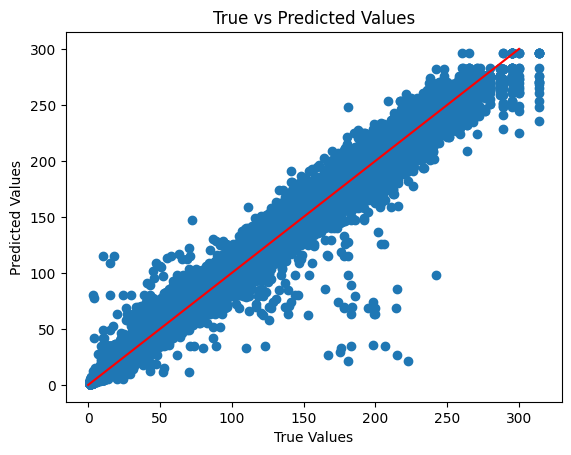

In [ ]:
plot_results(y_tree_train, y_tree_predict_train)

### check validation score

In [ ]:
y_tree_predict_val = best_decision_tree_regressor.predict(X_tree_val_scaled)

In [ ]:
get_results(y_tree_val, y_tree_predict_val)

,0
mse,18.9462
r2,0.9951
mae,2.6231
rmlse,0.2639


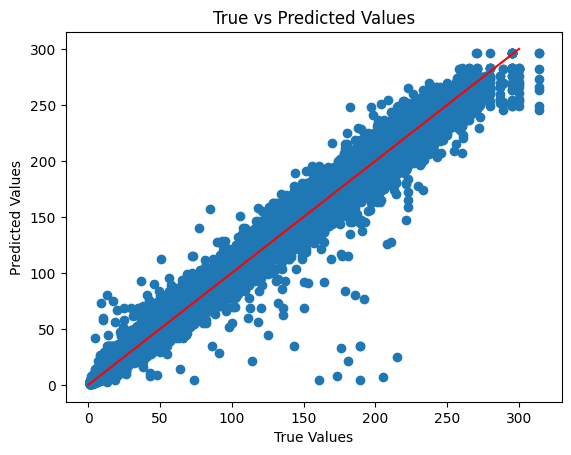

In [ ]:
plot_results(y_tree_val, y_tree_predict_val)

## Forests

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
cv_params = {'n_estimators' : [50,100],
              'max_depth' : [10,50],
              'min_samples_leaf' : [0.5,1],
              'min_samples_split' : [0.001, 0.01],
              'max_features' : ["sqrt"],
              'max_samples' : [.5,.9]}


In [ ]:
rf = RandomForestRegressor(random_state=0)

rf_cv = GridSearchCV(rf, cv_params, cv=5,
                    scoring = scoring,
                    # refit ='neg_root_mean_squared_error',
                     refit='neg_root_mean_squared_error',
                     n_jobs = -1, verbose = 1)

transformedRegressor_forest = TransformedTargetRegressor(
      regressor= rf_cv,
      func=np.log1p,
      inverse_func=np.expm1
)
pipe = make_pipeline(
    transformedRegressor_forest
    )
clf = pipe.fit(X_tree_train_scaled, y_tree_train)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
best_params = transformedRegressor_forest.regressor_.best_params_
best_params = pd.Series(best_params)
best_params

In [ ]:
best_forest_regressor = RandomForestRegressor(random_state = 0,)

In [ ]:
best_forest_regressor.fit(X_tree_train_scaled, y_tree_train)

In [ ]:
y_forest_predict_train = best_forest_regressor.predict(X_tree_train_scaled)

In [ ]:
get_results(y_tree_train, y_forest_predict_train)

In [ ]:
plot_results(y_tree_train, y_forest_predict_train)

### check validation score

In [ ]:
y_forest_predict_val = best_forest_regressor.predict(X_tree_val_scaled)

In [ ]:
get_results(y_tree_val, y_forest_predict_val)

In [ ]:
plot_results(y_tree_val, y_forest_predict_val)

### XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from sklearn.model_selection import KFold
from time import time
from xgboost import XGBRegressor

In [ ]:
xgb_regressor = XGBRegressor(
    objective ='reg:squarederror',
    booster = 'gbtree',
    eval_metric = 'rmse',
    device="cuda" if XGBRegressor().get_params().get("device") == "cuda"\
    else "cpu",
    random_state=0,
    learning_rate=0.0531, max_depth=10,
    min_child_weight=7, gamma=0.7593,
    subsample=0.8541, colsample_bytree=0.7027,
    reg_alpha=1.0995, reg_lambda=1.0626,
    n_estimators=500,
    enable_categorical = True)

In [ ]:
FOLDS = 50
kf = KFold(n_splits = FOLDS, shuffle = True, random_state = 42)
# Arrays to store predictions
oof_xgb = np.zeros(len(X_train_tree))
pred_xgb = np.zeros(len(X_test_tree))

In [ ]:
X_xgb_cv = X_train_tree[tree_features]
y_xgb_cv = y_train_tree

pipe_kf = TransformedTargetRegressor(
  regressor = xgb_regressor,
  func = np.log1p,
  inverse_func = np.expm1
)

for i, (train_index, val_index) in enumerate(kf.split(X_xgb_cv, y_xgb_cv)):
  print(f"Fold {i+1}")
  X_tree_train, X_tree_val = X_xgb_cv.iloc[train_index].copy(),\
                             X_xgb_cv.iloc[val_index].copy()
  y_tree_train, y_tree_val = y_xgb_cv.iloc[train_index], y_xgb_cv.iloc[val_index]

  pipe_kf.fit(X_tree_train, y_tree_train, \
                    eval_set=[(X_tree_val, y_tree_val)], \
                    verbose=100)

  oof_xgb[val_index] = pipe_kf.predict(X_tree_val)
  pred_xgb += pipe_kf.predict(X_test_tree[tree_features].copy())
  print(get_results(y_tree_val, oof_xgb[val_index]))

In [ ]:
# Average test predictions
y_fold_pred = pred_xgb / FOLDS

# Final RMSLE
get_results(y_xgb_cv, oof_xgb)

In [ ]:
plot_results(y_xgb_cv, oof_xgb)

In [ ]:
importances = pipe_kf.regressor_.feature_importances_
importances_pdf = pd.DataFrame(importances, index = X_xgb_cv.columns, columns=["importance"]).sort_values("importance", ascending=False)

# Create Submission .csv

In [ ]:
final_preds = X_test_tree[["id"]].copy()
final_preds["calories"] = y_fold_pred
final_preds.to_csv("./submission.csv", index=False)

In [ ]:
pd.read_csv("./submission.csv").head()